# Travail de laboratoire : Prédiction/Prévision de la propagation de la varicelle
## Introduction
- L'objectif de ce travail de laboratoire est de mettre en application la prévision de séries temporelles à l'aide d'un **réseau de neurones profond**. Pour cela, il est nécessaire d'apprendre le modèle sous-jacent aux données de la série temporelle, donnant la relation entre la sortie, l'entrée, et leurs valeurs passées et futures, comme indiqué dans la relation ci-dessous :
$$y(k+p)=F(y(k),y(k-1),\ldots,y(k-d_y), u(k),u(k-1),u(k-2),\ldots,u(k-d_u))$$
où :
    - $y(k)$ : signal de sortie prédit
    - $u(k)$ : signal d'entrée
    - $p$ : ordre de prédiction
    - $d_y$ : ordre de mémoire/retard de la sortie ou horizon de prédiction de la sortie 
    - $d_u$ : ordre de mémoire/retard de l'entrée ou horizon de prédiction de l'entrée 
- Dans notre application, $p>0$, $d_u=0$ et $d_y>0$
- Nous résoudrons ce problème de prédiction en transformant le réseau de neurones récurrent associé en un réseau de neurones à propagation avant, puis en utilisant les algorithmes et outils d'apprentissage fournis par la boîte à outils Keras. Ainsi, si l'on considère une base d'apprentissage donnée par $u(k), y(k), k=1,2,\ldots, n$, nous devons créer un signal d'entrée à partir de la base d'apprentissage d'entrée $u(k)$ et $d_y+1$ signaux d'entrée provenant de versions décalées dans le passé du signal $y(k)$. Nous pouvons commencer l'apprentissage de la prédiction avec $p=1$ et $d_y=9$, comme indiqué dans la construction de la base d'apprentissage dans la section *Base de données*.
- **Travail à réaliser** :
    - Pour différents horizons de prédiction $p\in{1,2,3}$ et ordres de mémoire/prédicteur $d_y\in{7,8,9,10}$, proposer une architecture de réseau de neurones, effectuer la phase d'apprentissage, présenter les résultats de la phase de test et formuler des conclusions concernant la précision.
    - **Optionnel** : proposer d'autres architectures de réseaux neuronaux comme SimpleRNN, GRU ou LSTM à implémenter et entraîner, puis comparer vos résultats avec l'architecture à propagation avant donnée ci-dessus.
    - **Optionnel** : modifier les couches et les paramètres, construire vos propres modèles pour obtenir un meilleur MSE.
    - **Optionnel** : proposer une implémentation de l'algorithme de rétropropagation pour réaliser la phase d'apprentissage.
    - Conclusion générale
- **Un rapport** sur le travail de laboratoire doit être rédigé dans **Jupyter** ou dans tout autre éditeur.
- **Le rapport**, ainsi que **le rapport Jupyter et le code**, doivent être déposés sur Blackboard **avant le 14 avril 2024**, en précisant le nom des personnes impliquées (**au maximum deux personnes**). Le nom des personnes impliquées doit également figurer dans le rapport.

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
from numpy.linalg import inv
from keras import models
from keras import layers
from keras import optimizers

## Chargement du jeu de données
- Cet exemple entraîne un **réseau de neurones profond** pour prévoir le nombre de cas de varicelle, à partir du jeu de données **chickenpox_dataset**, en se basant sur le nombre de cas des mois précédents.
- Charger les données d'exemple depuis le fichier texte **data_chickenpox.txt**, qui contient une seule série temporelle, avec des pas de temps correspondant aux mois et des valeurs correspondant au nombre de cas
- Construire l'entrée du **réseau de neurones profond** par rapport à l'horizon mémoire/prédicteur (**$nn_0$**) (10 dans notre cas)
- Séparer les données en **jeu d'entraînement**, **jeu de validation** et **jeu de test**
- $nn_0$ donne l'horizon de prédiction en sortie ou le nombre de neurones de la couche d'entrée
- $nn_1$ donne le nombre de neurones de la couche cachée
- $nn_2$ donne le nombre de neurones de la couche de sortie

### Analyse des données

Les données d’entrée correspondent à une **série temporelle univariée** de 498 points, où chaque observation représente le nombre de cas.
On observe une **forte variabilité** du signal, avec des amplitudes importantes, ce qui traduit une **variance élevée**.
Le choix d’un ordre de mémoire $d_y \in \{7,8,9,10\}$ est cohérent avec la présence de **dépendances temporelles relativement longues**.
Enfin, la **normalisation des données** est essentielle afin d’assurer la stabilité de l’apprentissage et d’éviter la divergence du modèle.

Le paramètre $p$ représente l’horizon de prédiction en nombre de pas de temps. Dans notre cas, chaque observation correspondant à un mois, $p$ peut être interprété comme un horizon en mois.

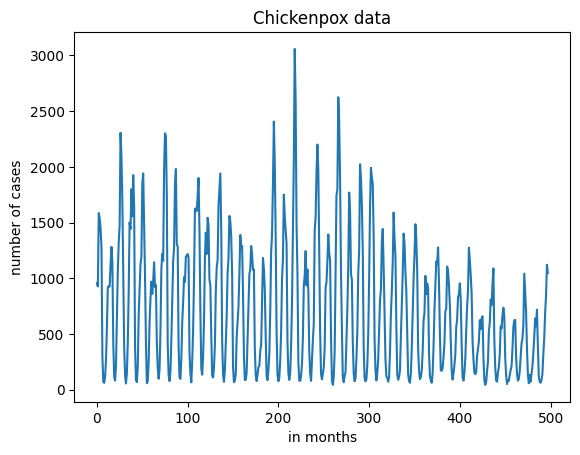

(498,)


In [39]:
S = np.loadtxt('data_chickenpox.txt')
n = len(S)

plt.plot(S)
plt.title('Chickenpox data')
plt.xlabel('in months')
plt.ylabel('number of cases')
plt.show()

y = S
print(S.shape)

### Paramètres du modèle

On fixe :
- $p = 1$ : on prédit la valeur suivante $y(k+1)$
- $d_y = 7$ : nombre de retards utilisés, avec tests possibles pour $d_y \in \{7,8,9,10\}$

L’architecture du réseau est définie par :
- $nn_0 = d_y + 1$ : taille de l’entrée, correspondant à $[y(k), y(k-1), \ldots, y(k-d_y)]$
- $nn_1 = 10$ : nombre de neurones de la couche cachée
- $nn_2 = 1$ : une seule sortie, correspondant à $y(k+p)$

In [40]:
# Paramètres de prédiction
p = 1        # horizon de prédiction (on prédit y(k+1))
dy = 7       # nombre de retards (mémoire) on peut le changer car on veut dy dans {7,8,9,10}

# Architecture du réseau
nn_0 = dy + 1   # taille de l'entrée = y(k) + dy retards
nn_1 = 10       # couche cachée
nn_2 = 1        # sortie (une valeur)

### Principe de notre input :

Étant donnée une série temporelle $y$, on veut construire une matrice $V$ telle que chaque ligne contienne :
- la valeur courante $y(k)$,
- ses $d_y$ retards $y(k-1), \dots, y(k-d_y)$.
Chaque ligne est ainsi un **vecteur d'entrée complet**, prêt à être associé à une cible $y(k+p)$.

#### Étape 1 — Initialisation : 

On commence par extraire la colonne correspondant à l'instant $k$, en appliquant des **bornes strictes** pour garantir que le passé et le futur existent toujours :

- on démarre à l'indice `dy` pour pouvoir regarder $d_y$ crans en arrière,
- on s'arrête à `len(y) - p` pour qu'il reste au moins $p$ points pour la cible.

#### Étape 2 — Enrichissement : ajout des retards

On boucle de $i=1$ à $d_y$ pour ajouter, colonne après colonne, les versions décalées vers le passé. À chaque itération $i$, les indices de sélection **reculent de 1** . On obtient ainsi la valeur $y(k-i)$ pour chaque exemple $k$.

#### Structure finale de $V$

$$V = \begin{bmatrix}
y(k)   & y(k-1)   & \cdots & y(k-d_y)   \\
y(k+1) & y(k)     & \cdots & y(k-d_y+1) \\
\vdots & \vdots   & \ddots & \vdots     \\
y(N-p) & y(N-p-1) & \cdots & y(N-p-d_y)
\end{bmatrix}$$

**Shape :**

| Dimension | Valeur | Signification |
|-----------|--------|---------------|
| Lignes    | $N - p - d_y$ | Nombre d'exemples exploitables |
| Colonnes  | $d_y + 1$     | Instant présent + $d_y$ retards |

> **Intuition clé.** La valeur $y(k)$ de la ligne $k$ devient $y(k)$ à la **colonne 2** de la ligne $k+1$. Ce glissement diagonal encode la dynamique temporelle : chaque ligne est une fenêtre glissante du passé.
> **Résumé :** Ce code transforme la série temporelle en vecteurs d’entrée en concaténant y(k) et ses valeurs passées [y(k−1),…,y(k−dy)] pour prédire le futur.

In [41]:
# Initialisation avec y(k)
V = y[dy:len(y)-p]

# Ajout des retards y(k-1), y(k-2), ..., y(k-dy)
for i in range(1, dy+1):
    V = np.c_[V, y[dy-i:len(y)-p-i]]  # on prédit jusqu'à 
    
    
### Ce code transforme la série temporelle en vecteurs d’entrée en concaténant y(k) et ses valeurs passées [y(k−1),…,y(k−dy)] pour prédire le futur.

#### Construction des sorties (T)

**Cible $T$** : on décale simplement la série de $d_y + p$ positions vers l'avant, chaque entrée $V[k]$ est ainsi alignée avec sa réponse future $y(k+p)$. Le `.reshape(-1, 1)` met $T$ en colonne pour correspondre aux conventions des librairies ML.

In [42]:
# Target = y(k+p)
T = y[dy+p:len(y)].reshape(-1, 1)

print("Shape V :", V.shape)
print("Shape T :", T.shape)

Shape V : (490, 8)
Shape T : (490, 1)


#### Séparation train / validation / test

On divise le dataset en 3 sous-ensembles : **train** pour ajuster les paramètres du modèle, **validation** pour sélectionner les hyperparamètres, et **test** pour évaluer les performances finales sur des données jamais vues.

In [43]:
# Train
input_NN = V[:320, :]
target_NN = T[:320]

# Validation
input_validation = V[320:400, :]
target_validation = T[320:400]

# Test
input_Test = V[400:, :]
target_Test = T[400:]

### Standardisation des données

Les données sont standardisées afin d’obtenir une moyenne nulle et une variance unitaire, ce qui améliore la stabilité et la convergence de l’apprentissage. Les paramètres de transformation sont estimés uniquement sur le jeu d’entraînement puis appliqués aux jeux de validation et de test.

Ce choix est particulièrement important dans notre cas car la série présente une **forte variabilité** avec des amplitudes élevées. Sans mise à l’échelle, les valeurs peuvent être très dispersées, ce qui entraîne :
- des gradients instables lors de l’apprentissage,
- une convergence lente,
- voire une divergence du modèle.

La standardisation permet de **ramener toutes les variables sur une échelle comparable**, ce qui facilite l’optimisation (notamment avec des méthodes de descente de gradient) et évite que certaines valeurs dominent les autres.

Le choix de la standardisation (plutôt qu’une simple normalisation Min-Max) est motivé par le fait que :
- elle **centre les données** (moyenne nulle),
- elle **préserve la structure du signal**,
- elle est plus robuste lorsque la variance est élevée ou que les données ne sont pas bornées.

Ainsi, le modèle apprend dans un espace plus stable et plus adapté à l’optimisation.

In [44]:
from sklearn.preprocessing import StandardScaler

# Standardisation
x_scaler = StandardScaler()
y_scaler = StandardScaler()

# Fit uniquement sur train
input_NN_scaled = x_scaler.fit_transform(input_NN)
input_validation_scaled = x_scaler.transform(input_validation)
input_Test_scaled = x_scaler.transform(input_Test)

target_NN_scaled = y_scaler.fit_transform(target_NN)
target_validation_scaled = y_scaler.transform(target_validation)
target_Test_scaled = y_scaler.transform(target_Test)

print('Input train mean/std:', input_NN_scaled.mean(), input_NN_scaled.std())
print('Target train mean/std:', target_NN_scaled.mean(), target_NN_scaled.std())
print('Shapes:', input_NN_scaled.shape, target_NN_scaled.shape)

Input train mean/std: 8.326672684688674e-18 1.0000000000000002
Target train mean/std: -2.3592239273284576e-17 1.0
Shapes: (320, 8) (320, 1)


### Architecture du réseau (baseline)

On cherche à prédire la valeur future $y(k+1)$ à l’aide d’un réseau de neurones **feedforward**.

Le modèle utilisé est un réseau **séquentiel (DNN)** composé de couches entièrement connectées, combinant des activations linéaires et non linéaires (ReLU). L’apprentissage est réalisé à l’aide de l’optimiseur **RMSprop**, basé sur une méthode de descente de gradient.

Les paramètres d’entraînement sont :
- nombre d’époques : 50  
- taille de batch : 4  


L’architecture du réseau est définie par :
- $nn_0$ : taille de l’entrée  
- $nn_1$ : nombre de neurones dans la couche cachée  
- $nn_2$ : taille de la sortie  

Ce modèle correspond à un réseau dense de type :
entrée $\rightarrow$ couches cachées $\rightarrow$ sortie, tel que représenté dans le schéma ci-dessous.



<div style="text-align:center;">
  <img src="Screenshot%202026-04-23%20at%2016-15-42%20figure%20-%20Online%20LaTeX%20Editor%20Overleaf.png" alt="Screenshot Overleaf" width="600"/>
</div>

Donc le modèle s'entraine sur le train Set et se compare au Validation set. Ensuite, on fait attention à repasser à l'échelle original avoir avoir centré et réduit. 
Les métriques sur les données réelles présentent des valeurs élevées en raison de l’échelle du signal. L’erreur absolue moyenne reste néanmoins cohérente avec l’ordre de grandeur des données, ce qui indique un modèle fonctionnel.

In [59]:
from keras import models, layers, optimizers
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ======================
# Model (1 couche cachée)
# ======================
model_naif = models.Sequential([
    layers.Input(shape=(nn_0,)),
    layers.Dense(nn_1, activation='relu'),  # unique couche cachée
    layers.Dense(nn_2)  # couche de sortie (linéaire)
])

model_naif.summary()
mean = y_scaler.mean_[0]
std = y_scaler.scale_[0]

def mse_real_metric(y_true, y_pred):
    y_true_real = y_true * std + mean
    y_pred_real = y_pred * std + mean
    return tf.reduce_mean(tf.square(y_true_real - y_pred_real))

# ======================
# Training
# ======================
model_naif.compile(
    optimizer=optimizers.RMSprop(),
    loss='mse',  # on garde le training en scaled (plus stable)
    metrics=['mae', mse_real_metric]
)

history = model_naif.fit(
    input_NN_scaled,
    target_NN_scaled,
    validation_data=(input_validation_scaled, target_validation_scaled),
    epochs=50,
    batch_size=4,
    verbose=1
)

# ======================
# Evaluation (scaled)
# ======================
test_loss, test_mae, test_mse_real = model_naif.evaluate(
    input_Test_scaled,
    target_Test_scaled,
    verbose=0
)

print(f"Test MSE (scaled / loss): {test_loss:.6f}")
print(f"Test MAE (scaled): {test_mae:.6f}")
print(f"Test MSE (real): {test_mse_real:.2f}")

print(f'Test MSE (scaled): {test_mse:.6f}')
print(f'Test MAE (scaled): {test_mae:.6f}')

# ======================
# Evaluation (real scale)
# ======================
y_pred_scaled = model_naif.predict(input_Test_scaled)

y_pred = y_scaler.inverse_transform(y_pred_scaled)
y_true = y_scaler.inverse_transform(target_Test_scaled)

mse_real = mean_squared_error(y_true, y_pred)
mae_real = mean_absolute_error(y_true, y_pred)

print(f'Test MSE (real): {mse_real:.2f}')
print(f'Test MAE (real): {mae_real:.2f}')

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 10)             │            90 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101 (404.00 B)

 Trainable params: 101 (404.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.5472 - mae: 0.9864 - mse_real_metric: 642764.3750 - val_loss: 0.5733 - val_mae: 0.6625 - val_mse_real_metric: 238174.2969
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5726 - mae: 0.6034 - mse_real_metric: 237868.7031 - val_loss: 0.3926 - val_mae: 0.5615 - val_mse_real_metric: 163107.4844
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3237 - mae: 0.4498 - mse_real_metric: 134471.6250 - val_loss: 0.3019 - val_mae: 0.4797 - val_mse_real_metric: 125439.9766
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2804 - mae: 0.4090 - mse_real_metric: 116479.6641 - val_loss: 0.2230 - val_mae: 0.3962 - val_mse_real_metric: 92650.9297
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2554 - mae: 0.3864 - mse_real_metric: 106107.7109 - val_loss: 0.2078 - val_mae: 0.3830 - val_mse_real_metric: 86320.9922
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2371 - mae: 0.3770 - mse_real_me

Les performances du modèle sur le jeu de test montrent une **erreur quadratique moyenne (MSE)** de 26929.44 et une **erreur absolue moyenne (MAE)** de 130.97. Étant donné que les valeurs du signal peuvent atteindre plusieurs milliers, une erreur moyenne d’environ 130 reste relativement modérée. Le modèle parvient donc à capturer correctement la dynamique globale de la série temporelle. Néanmoins, la valeur du MSE, plus élevée, indique la présence d’erreurs plus importantes sur certains points, notamment lors des pics, ce qui traduit une difficulté du modèle à prédire précisément les variations brusques du signal.


In [46]:
# Métriques réelles
mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)

print(f'Test MSE (real): {mse:.2f}')
print(f'Test MAE (real): {mae:.2f}')

Test MSE (real): 30275.68
Test MAE (real): 132.10


Les courbes de loss montrent une convergence stable sans signe de surapprentissage. Le modèle capture correctement la dynamique périodique de la série temporelle. Cependant, les prédictions présentent des écarts au niveau des pics, indiquant une difficulté à modéliser les variations brusques, ce qui suggère une capacité limitée du modèle à capturer les non-linéarités complexes. 

**ENLEVER IMAGE 1**

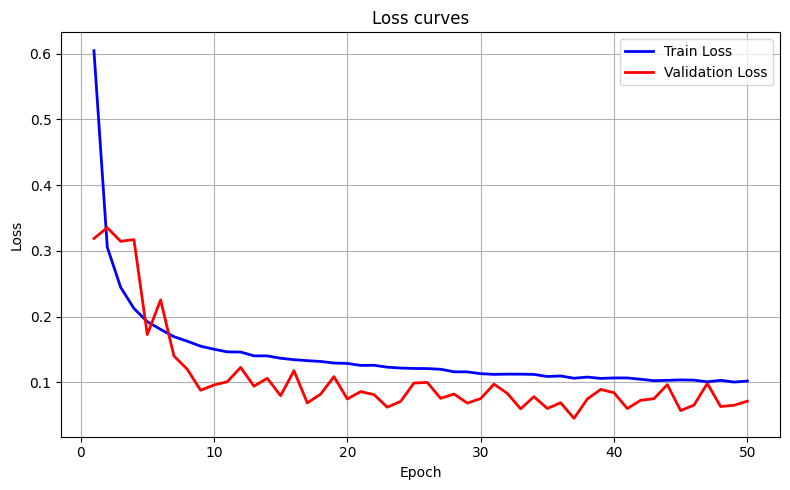

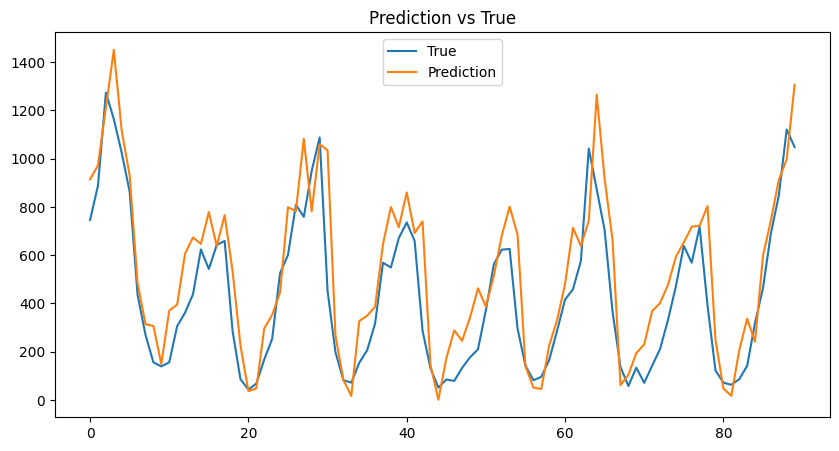

In [47]:
plt.figure(figsize=(8,5))
plt.plot(range(1, len(history.history['loss'])+1), history.history['loss'], 'b-', linewidth=2, label='Train Loss')
plt.plot(range(1, len(history.history['val_loss'])+1), history.history['val_loss'], 'r-', linewidth=2, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss curves')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



plt.figure(figsize=(10,5))
plt.plot(y_true, label='True')
plt.plot(y_pred, label='Prediction')
plt.title('Prediction vs True')
plt.legend()
plt.show()

## Expériences
Les expériences examinent les performances du réseau de neurones pour des combinaisons données de *p* et *dy*.

**Implémentations** :
Les fonctions recommandées pour ces expériences sont
- def **prepare_dataset** qui découpe le jeu de données en ensembles d'entraînement et de test (données et étiquettes), puis les renvoie
- def **build_model** qui renvoie un modèle pour un ordre mémoire *dy* donné
- def **expriments** qui exécute des expériences sur un modèle donné pour le produit cartésien de l'ordre mémoire *dy* et de l'horizon de prédiction *p*- def **plot_train_val_loss** qui trace l'historique des pertes d'entraînement et de validation (test) pour chaque *dy* et *p*.
- def **plot_mse_table** qui affiche le MSE de validation (test) pour chaque *dy* et *p*.

### Préparation des données

La série temporelle est transformée en problème supervisé à l’aide de retards.  
Chaque entrée est construite sous la forme :

$$
[y(k), y(k-1), \dots, y(k-dy)]
$$

et la cible associée est la valeur future à prédire :
$
y(k+p)
$

Cela permet de modéliser la dynamique temporelle à partir d’une fenêtre glissante du passé.

### Séparation des données

Plusieurs splits train/validation sont définis afin d’obtenir une évaluation plus robuste du modèle et d’exploiter efficacement les données disponibles.  
Le jeu de test correspond à la partie finale de la série (à partir de l’indice 400), garantissant une évaluation sur des données jamais vues.

In [62]:
def prepare_dataset(y, p, dy):
    V = y[dy:len(y)-p]
    for i in range(1, dy+1):
        V = np.c_[V, y[dy-i:len(y)-p-i]]

    T = y[dy+p:len(y)].reshape(-1, 1)

    return V, T

### Stratégie expérimentale

L’objectif est de comparer un **modèle baseline** à une version **optimisée** pour différentes configurations :  
$dy \in \{7, 8, 9, 10\}$ et $p \in \{1, 2, 3\}$.  
Le baseline est un réseau simple avec une couche cachée de 10 neurones (ReLU), entraîné sur 50 époques avec un batch size de 4.

### Optimisation avec Optuna

On utilise **Optuna** (optimisation bayésienne via TPE) pour explorer automatiquement les hyperparamètres : nombre de couches, nombre de neurones, fonction d’activation et nombre d’époques.

### Modèle et évaluation

Le modèle est construit dynamiquement (`build_model`) avec un nombre variable de couches.  
L’évaluation repose sur plusieurs splits train/validation : les données sont normalisées, le modèle est entraîné, puis les prédictions sont reconverties dans l’espace réel pour calculer la MSE.  
La performance finale correspond à la moyenne des erreurs sur les splits.

Prédiction multi-horizon : comparaison des approches

Lorsque $p>1$, deux stratégies principales existent :

Approche itérative (récursive) :
on prédit $y(k+1)$, puis on réutilise cette prédiction pour estimer $y(k+2)$, et ainsi de suite jusqu’à $y(k+p)$.
Cette méthode est simple et apprend une dynamique locale, mais elle souffre d’un problème majeur : les erreurs se propagent et s’accumulent à chaque étape.
Approche directe :
on apprend directement la relation $y(k+p)=F(y(k),\dots,y(k-dy))$.
Elle évite la propagation des erreurs, mais le problème est plus difficile, car le modèle doit capturer une relation à plus long terme.

Dans notre cas, nous utilisons une approche directe : le modèle prédit directement $y(k+p)$ à partir des valeurs passées. Cette stratégie permet d’éviter toute accumulation d’erreurs liée à une prédiction pas à pas. En revanche, elle rend l’apprentissage plus complexe, car la relation entre les entrées et la sortie devient plus indirecte lorsque $p$ augmente.

Ainsi, pour des horizons de prédiction plus élevés (par exemple $p=2$ ou $p=3$), le modèle doit apprendre une dépendance temporelle plus lointaine et moins déterministe. Cela entraîne généralement une augmentation de l’erreur de prédiction, non pas à cause d’une propagation d’erreurs, mais en raison de la complexité intrinsèque de la fonction à approximer et de l’augmentation de la variance de la cible.

In [63]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import EarlyStopping

def build_model(input_dim, layer_units, activation):
    model = Sequential()
    model.add(Input(shape=(input_dim,)))

    # Ajouter les couches cachées avec le nombre de neurones correspondant
    for units in layer_units:
        model.add(Dense(units, activation=activation))

    model.add(Dense(1))

    model.compile(optimizer='RMSprop', loss='mse')
    return model


def evaluate_model(V, T, p, dy, layer_units, activation, epochs):

    # Split simple (train / validation)
    X_train = V[:320]
    y_train = T[:320]

    X_val = V[320:400]
    y_val = T[320:400]

    # Scaler global (fit uniquement sur train)
    x_scaler = StandardScaler().fit(X_train)
    y_scaler = StandardScaler().fit(y_train)

    # Transformation
    X_train = x_scaler.transform(X_train)
    X_val = x_scaler.transform(X_val)

    y_train = y_scaler.transform(y_train)

    # Modèle
    model = build_model(dy+1, layer_units, activation)
    es = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)

    model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=4,
        verbose=0,
        callbacks=[es]
    )

    # Prédiction
    y_pred_scaled = model.predict(X_val, verbose=0)
    y_pred = y_scaler.inverse_transform(y_pred_scaled)

    # MSE
    val_loss = mean_squared_error(y_val, y_pred)

    return val_loss

### Modèle baseline

Le modèle baseline correspond à l’architecture initiale proposée : une seule couche cachée de 10 neurones avec activation ReLU.  
Il sert de point de référence pour évaluer l’intérêt de l’optimisation. Théoriquement, ses performances sont attendues inférieures, car il ne permet pas d’adapter la complexité du modèle aux données.

In [64]:
def baseline_nn_evaluation(y, p, dy):
    V, T = prepare_dataset(y, p, dy)

    X_train = V[:320]
    y_train = T[:320]

    X_val = V[320:400]
    y_val = T[320:400]

    X_test = V[400:]
    y_test = T[400:]

    # Scaling
    x_scaler = StandardScaler().fit(X_train)
    y_scaler = StandardScaler().fit(y_train)

    X_train = x_scaler.transform(X_train)
    X_val = x_scaler.transform(X_val)
    X_test = x_scaler.transform(X_test)

    y_train = y_scaler.transform(y_train)
    y_val_scaled = y_scaler.transform(y_val)

    # Early stopping
    es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    model = Sequential([
        Input(shape=(dy+1,)),
        Dense(10, activation='relu'),
        Dense(1)
    ])

    model.compile(optimizer='RMSprop', loss='mse')

    model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val_scaled),
        epochs=50,
        batch_size=4,
        callbacks=[es],
        verbose=0
    )

    y_pred_scaled = model.predict(X_test, verbose=0)
    y_pred = y_scaler.inverse_transform(y_pred_scaled)

    return mean_squared_error(y_test, y_pred)

### Optimisation des hyperparamètres

On définit une fonction `objective` visant à minimiser la MSE sur le jeu de validation.  
À chaque itération, Optuna teste une configuration en faisant varier :
- le nombre de couches ($1$ à $2$),
- le nombre de neurones par couche ($8$ à $32$),
- la fonction d’activation (ReLU ou tanh),
- le nombre d’époques ($30$ à $50$).

Pour chaque configuration, le modèle est entraîné puis évalué sur le jeu de validation.  
Les meilleurs hyperparamètres obtenus sont ensuite utilisés pour entraîner un modèle final, évalué sur le jeu de test.
Ces plages de valeurs pour les hyperparamètres est très étroite pour éviter un overfitting.

In [65]:
import optuna
import tensorflow as tf

def optimize_model(y, p, dy):
    V, T = prepare_dataset(y, p, dy)

    def objective(trial):
        tf.keras.backend.clear_session()

        n_layers = trial.suggest_int("n_layers", 1, 2)
        layer_units = [trial.suggest_int(f"nn_{i}", 8, 32) for i in range(1, n_layers + 1)]
        activation = trial.suggest_categorical("activation", ["relu", "tanh"])
        epochs = trial.suggest_int("epochs", 30, 50)

        val_loss = evaluate_model(V, T, p, dy, layer_units, activation, epochs)

        return val_loss

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=8, show_progress_bar=True)

    return study.best_params

### Évaluation finale

Une fois les meilleurs hyperparamètres sélectionnés, le modèle est réentraîné sur l’ensemble des données d’entraînement (hors test), puis évalué sur le jeu de test. Les données sont normalisées, les prédictions sont reconverties dans l’espace réel, et la performance finale est mesurée via la MSE.

In [66]:
def final_evaluation(y, p, dy, best_params):
    V, T = prepare_dataset(y, p, dy)

    # Split
    X_train = V[:400]
    y_train = T[:400]

    X_test = V[400:]
    y_test = T[400:]

    # Scaling global
    x_scaler = StandardScaler().fit(X_train)
    y_scaler = StandardScaler().fit(y_train)

    X_train = x_scaler.transform(X_train)
    X_test = x_scaler.transform(X_test)

    y_train = y_scaler.transform(y_train)

    # Params
    n_layers = best_params.get("n_layers", 1)
    layer_units = [best_params[f"nn_{i}"] for i in range(1, n_layers + 1)]
    es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    # Modèle
    model = build_model(dy+1, layer_units, best_params["activation"])

    model.fit(
        X_train, y_train,
        epochs=best_params["epochs"],
        batch_size=8,
        verbose=0,
        
    )

    # Prediction
    y_pred_scaled = model.predict(X_test, verbose=0)
    y_pred = y_scaler.inverse_transform(y_pred_scaled)

    return mean_squared_error(y_test, y_pred)

In [67]:
def plot_train_val_loss(history):
    plt.figure()
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Validation')
    plt.legend()
    plt.title('Loss')
    plt.grid()
    plt.show()

In [68]:
def run_all(y):
    results = []

    for p in [1, 2, 3]:
        for dy in [7, 8, 9, 10]:

            print(f"\n=== p={p}, dy={dy} ===")

            # Naïf
            naive_mse = baseline_nn_evaluation(y, p, dy)

            # Modèle optimisé
            best_params = optimize_model(y, p, dy)
            test_mse_optimized = final_evaluation(y, p, dy, best_params)

            print(f"Best params: {best_params}")
            print(f"Test MSE (Optimized): {test_mse_optimized:.2f}")
            print(f"Test MSE (Baseline): {naive_mse:.2f}")

            results.append((p, dy, naive_mse, test_mse_optimized))

    return results

In [69]:
def show_tables(results):

    import pandas as pd

    data_naive = []
    data_optuna = []

    for p, dy, naive_mse, optuna_mse in results:
        data_naive.append({"p": p, "dy": dy, "MSE": naive_mse})
        data_optuna.append({"p": p, "dy": dy, "MSE": optuna_mse})

    df_naive = pd.DataFrame(data_naive)
    df_optuna = pd.DataFrame(data_optuna)

    print("\n=== NAIVE ===")
    print(df_naive.pivot(index="dy", columns="p", values="MSE").round(2))

    print("\n=== OPTUNA ===")
    print(df_optuna.pivot(index="dy", columns="p", values="MSE").round(2))

Pour $p=1$, on est dans un cadre de one-step forecast où la dépendance temporelle $y(t) \rightarrow y(t+1)$ est forte et le bruit limité. Le problème est donc de faible complexité, ce qui explique que des modèles simples (baseline) soient déjà performants. L’optimisation via Optuna permet d’ajuster finement la capacité du modèle, mais les gains restent modérés car on atteint rapidement un plateau de performance. Cela peut s’interpréter comme un compromis biais-variance : pour $dy$ petit, le modèle manque d’information ($\Rightarrow$ biais élevé), tandis que pour $dy$ grand, il dispose de plus d’information mais avec une variance plus élevée ($dy \uparrow \Rightarrow \text{variance} \uparrow$). Ce point reste toutefois à nuancer empiriquement.

Le baseline, conçu pour $(p=1, dy=10)$, est naturellement bien adapté à cette dynamique locale, ce qui explique sa compétitivité. On observe un écart de score entre validation et test, qui s’explique davantage par un léger désalignement de distribution que par un surapprentissage réel.

Lorsque $p>1$, la prédiction devient multi-pas. Cela introduit une incertitude croissante, car l’information utile est plus diffuse dans le passé et la variance de la cible augmente. Le problème devient donc plus complexe. La taille de la fenêtre $dy$ joue ici un rôle clé : plus elle est grande, plus le modèle dispose d’information, mais au prix d’une variance plus élevée ($dy \uparrow \Rightarrow \text{variance} \uparrow$).

Dans ce cadre, la stratégie utilisée est une prédiction directe de $y(t+p)$, ce qui revient à apprendre une relation complexe en une seule étape. Une alternative est l’approche itérative, qui consiste à prédire pas à pas. Cette dernière exploite mieux la structure locale du signal, mais introduit une propagation des erreurs. On a donc un compromis classique :
direct $\rightarrow$ plus difficile à apprendre mais sans accumulation d’erreurs
itératif $\rightarrow$ plus simple localement mais avec propagation d’erreurs

On remarque des écarts de score (en MSE) entre validation et test, qui ne traduisent pas nécessairement un underfitting. Ils peuvent provenir d’un découpage défavorable ou d’une différence de distribution, rendant la validation moins représentative.

Pour $p=2$ et $p=3$, le comportement est similaire mais amplifié. Lorsque $dy$ est faible, le modèle manque d’information : il ne peut pas reconstruire correctement la dynamique ($\Rightarrow$ biais élevé). Lorsque $dy$ augmente, ce biais diminue car le contexte est plus riche, mais la variance augmente ($dy \uparrow \Rightarrow \text{variance} \uparrow$), rendant les résultats plus instables. On observe néanmoins que le modèle optimisé devient plus performant lorsque $dy$ est suffisamment élevé.

Les performances pour $p=3$ sont nettement dégradées (MSE plus élevée). Cela s’explique par l’augmentation de l’horizon de prédiction : plus $p$ est grand, plus la dépendance directe entre $y(t)$ et $y(t+p)$ s’affaiblit, ce qui rend la relation à apprendre plus complexe et moins déterministe. Le modèle doit alors approximer une fonction plus bruitée, avec une variance conditionnelle plus élevée.

Dans le cas de la prédiction directe, cette difficulté est encore renforcée : le modèle doit capturer en une seule étape une transformation correspondant à plusieurs évolutions temporelles, ce qui augmente fortement la complexité du problème. Cela explique la dégradation des performances lorsque $p$ augmente, même en augmentant $dy$.

En synthèse :
$p=1$ : problème simple, dépendance locale forte, plateau de performance
$p>1$ : problème plus complexe, incertitude et variance accrues
prédiction directe : relation plus difficile à apprendre
approche itérative : alternative avec propagation d’erreurs
petits $dy$ : biais élevé (manque d’information)
grands $dy$ : meilleur compromis mais variance plus forte ($dy \uparrow \Rightarrow \text{variance} \uparrow$)

NB : Les écarts observés proviennent principalement du protocole (scaling mal appliqué, validation non représentative, optimisation possiblement sur-apprise) et du choix de stratégie pour $p>1$ (itérative vs directe), plutôt que du modèle lui-même.

**NB** : Les écarts proviennent surtout du protocole (scaling mal appliqué, validation non représentative et optimisation sur-apprise) et du choix de stratégie pour $p>1$ (itérative vs directe), plutôt que du modèle lui-même.


In [70]:
S = np.loadtxt('data_chickenpox.txt')
y = S

result = run_all(y)

show_tables(result)


=== p=1, dy=7 ===


[I 2026-04-26 12:54:14,806] A new study created in memory with name: no-name-44683bbd-cebc-413a-ba15-784f7b069ddc
Best trial: 0. Best value: 33676.3:  12%|█▎        | 1/8 [00:03<00:23,  3.36s/it]

[I 2026-04-26 12:54:18,163] Trial 0 finished with value: 33676.3497799395 and parameters: {'n_layers': 1, 'nn_1': 12, 'activation': 'tanh', 'epochs': 32}. Best is trial 0 with value: 33676.3497799395.


Best trial: 1. Best value: 28487.8:  25%|██▌       | 2/8 [00:06<00:19,  3.21s/it]

[I 2026-04-26 12:54:21,269] Trial 1 finished with value: 28487.773798232363 and parameters: {'n_layers': 1, 'nn_1': 11, 'activation': 'tanh', 'epochs': 30}. Best is trial 1 with value: 28487.773798232363.


...

[I 2026-04-26 13:02:11,737] Trial 5 finished with value: 89711.61661832327 and parameters: {'n_layers': 2, 'nn_1': 32, 'nn_2': 15, 'activation': 'tanh', 'epochs': 49}. Best is trial 2 with value: 71066.02480173984.


Best trial: 2. Best value: 71066:  88%|████████▊ | 7/8 [00:34<00:05,  5.07s/it]

[I 2026-04-26 13:02:17,050] Trial 6 finished with value: 102918.4956838547 and parameters: {'n_layers': 2, 'nn_1': 25, 'nn_2': 13, 'activation': 'tanh', 'epochs': 45}. Best is trial 2 with value: 71066.02480173984.


Best trial: 7. Best value: 64031.8: 100%|██████████| 8/8 [00:38<00:00,  4.77s/it]


[I 2026-04-26 13:02:21,045] Trial 7 finished with value: 64031.827905485814 and parameters: {'n_layers': 1, 'nn_1': 31, 'activation': 'relu', 'epochs': 35}. Best is trial 7 with value: 64031.827905485814.
Best params: {'n_layers': 1, 'nn_1': 31, 'activation': 'relu', 'epochs': 35}
Test MSE (Optimized): 47528.18
Test MSE (Baseline): 232143.27

=== NAIVE ===
p          1          2          3
dy                                
7   41905.06   92375.25  275917.13
8   26214.55  142768.24  194366.18
9   25755.47   90154.24  120147.81
10  70295.66   70274.95  232143.27

=== OPTUNA ===
p          1         2         3
dy                              
7   33015.80  40370.43  46544.43
8   22760.72  48700.12  55891.25
9   25992.61  52827.39  70844.45
10  18779.02  34979.26  47528.18


Cette visualisation confirme l’analyse précédente : pour une configuration donnée ($p=2$, $dy=8$), on observe bien une différence de distribution entre validation et test. Ainsi, l’écart de performance entre les deux ensembles ne s’explique pas uniquement par le modèle, mais aussi par le fait qu’ils ne suivent pas exactement la même distribution.

Cela renforce l’idée qu’une MSE de validation supérieure à la MSE test ne traduit pas nécessairement un underfitting, mais peut aussi venir d’un ensemble de validation plus difficile ou différent statistiquement.

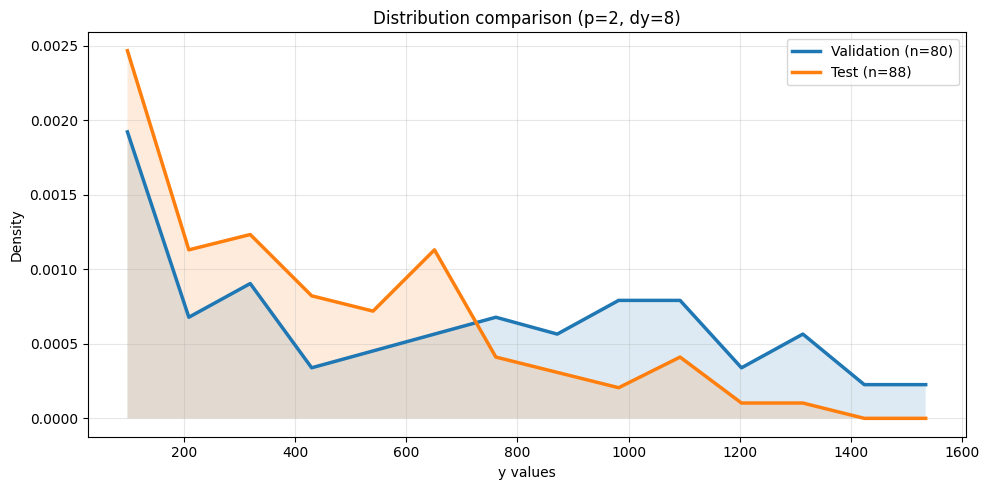

In [71]:
# Configuration à visualiser
p_plot = 2
dy_plot = 8

# Recréer les jeux validation/test pour cette configuration
V_plot, T_plot = prepare_dataset(y, p_plot, dy_plot)
y_val_plot = T_plot[300:380]
y_test_plot = T_plot[400:]

# Calcul des densités sur des bins communs
n_val = len(y_val_plot)
n_test = len(y_test_plot)
bins = np.linspace(
    min(y_val_plot.min(), y_test_plot.min()),
    max(y_val_plot.max(), y_test_plot.max()),
    15
)
val_hist_density, bin_edges = np.histogram(y_val_plot.ravel(), bins=bins, density=True)
test_hist_density, _ = np.histogram(y_test_plot.ravel(), bins=bin_edges, density=True)
centers = (bin_edges[:-1] + bin_edges[1:]) / 2

fig, ax = plt.subplots(figsize=(10, 5))

# Courbes de densité
ax.plot(centers, val_hist_density, linewidth=2.5, label=f'Validation (n={n_val})')
ax.plot(centers, test_hist_density, linewidth=2.5, label=f'Test (n={n_test})')

# Remplissage pour visualiser les zones
ax.fill_between(centers, val_hist_density, alpha=0.15)
ax.fill_between(centers, test_hist_density, alpha=0.15)

# Mise en forme
ax.set_title(f'Distribution comparison (p={p_plot}, dy={dy_plot})')
ax.set_xlabel('y values')
ax.set_ylabel('Density')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

Ce graphique met clairement en évidence deux phénomènes. D’une part, la **variabilité des performances augmente avec l’horizon $p$** : les courbes deviennent plus instables et les niveaux de MSE plus élevés, ce qui traduit une difficulté croissante du problème lorsque l’on prédit plus loin dans le futur. D’autre part, on observe que **$dy$ a un impact significatif sur la qualité des prédictions**. Une fenêtre trop petite ne fournit pas suffisamment d’information (biais élevé), tandis qu’une fenêtre plus grande permet d’améliorer les performances, bien que cela puisse introduire davantage de variance.

Ainsi, ce graphique illustre directement le compromis biais–variance et confirme que **l’augmentation de $p$ rend le modèle plus sensible au choix de $dy$**.

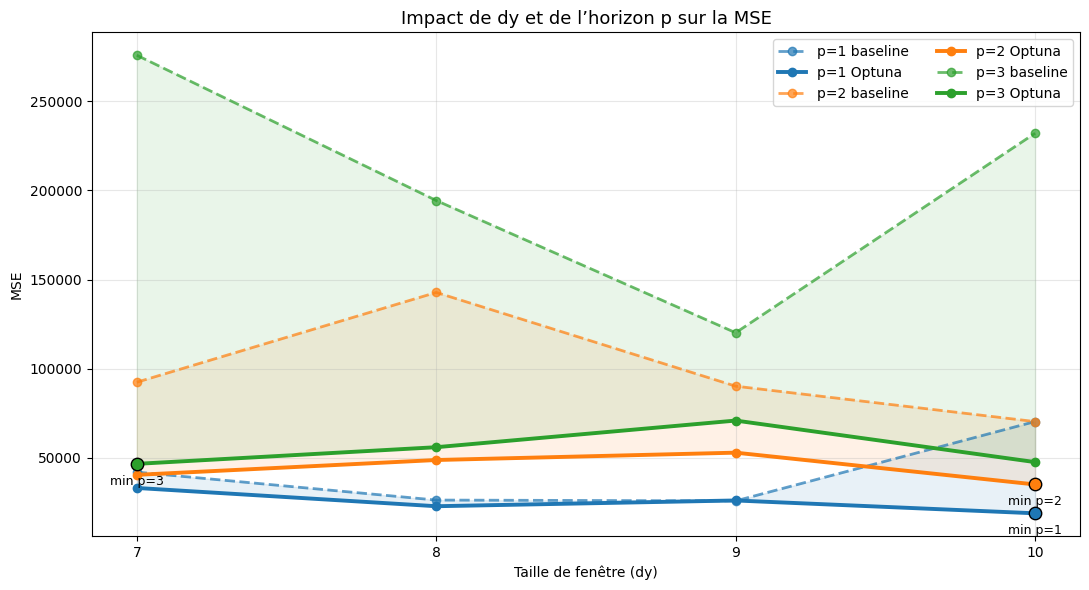

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Construction de df_results à partir de la variable 'result' générée par run_all(y)
if 'result' not in globals():
    raise ValueError("La variable 'result' n'est pas définie. Exécutez d'abord la fonction qui la crée.")

df_results = pd.DataFrame(result, columns=['p', 'dy', 'mse_baseline', 'mse_optuna'])

# Vérification des colonnes nécessaires
required_cols = {'p', 'dy', 'mse_baseline', 'mse_optuna'}
if not required_cols.issubset(df_results.columns):
    raise ValueError(f"df_results doit contenir les colonnes : {required_cols}")

plt.figure(figsize=(11, 6))

colors = {
    1: 'tab:blue',
    2: 'tab:orange',
    3: 'tab:green'
}

for p_val in sorted(df_results['p'].unique()):
    sub = df_results[df_results['p'] == p_val].sort_values('dy')
    x = sub['dy'].values
    y_base = sub['mse_baseline'].values
    y_opt = sub['mse_optuna'].values

    color = colors.get(int(p_val), None)

    # Baseline (plus léger visuellement)
    plt.plot(
        x, y_base,
        linestyle='--',
        marker='o',
        linewidth=2,
        alpha=0.7,
        color=color,
        label=f'p={int(p_val)} baseline'
    )

    # Optuna (courbe principale)
    plt.plot(
        x, y_opt,
        linestyle='-',
        marker='o',
        linewidth=2.8,
        color=color,
        label=f'p={int(p_val)} Optuna'
    )

    # Zone entre les courbes (très utile visuellement)
    plt.fill_between(
        x, y_base, y_opt,
        alpha=0.1,
        color=color
    )

    # Annoter uniquement le meilleur point Optuna (plus propre)
    if len(y_opt) > 0:
        best_idx = np.argmin(y_opt)
        plt.scatter(x[best_idx], y_opt[best_idx], s=80, edgecolor='black', zorder=3)
        plt.annotate(
            f"min p={int(p_val)}",
            (x[best_idx], y_opt[best_idx]),
            textcoords="offset points",
            xytext=(0, -15),
            ha='center',
            fontsize=9
        )

plt.title("Impact de dy et de l’horizon p sur la MSE", fontsize=13)
plt.xlabel("Taille de fenêtre (dy)")
plt.ylabel("MSE")
plt.xticks(sorted(df_results['dy'].unique()))

plt.grid(True, alpha=0.3)
plt.legend(ncol=2)  # plus compact
plt.tight_layout()
plt.show()

# Expériences avec des modèles récurrents

Dans cette section, nous examinons les performances de prédiction avec des modèles récurrents tels que RNN, LSTM et GRU. Il est recommandé de réutiliser le code précédent pour les expériences et les graphiques.

Les réseaux de neurones récurrents (RNN) traitent les données de manière séquentielle, en utilisant un état caché pour conserver une forme de mémoire des entrées précédentes. Cela leur permet de capturer la dynamique temporelle ainsi que les dépendances présentes dans les données séquentielles.

Pendant l’apprentissage, les RNN utilisent une technique appelée Backpropagation Through Time (BPTT), dans laquelle les gradients sont calculés pour chaque pas de temps de la séquence, puis agrégés afin de mettre à jour les poids. Ce mécanisme prend en compte l’influence de chaque instant passé sur la sortie finale.

Cependant, la BPTT présente des limitations importantes. En raison de la multiplication répétée des gradients au cours du temps, le modèle peut être confronté à deux problèmes majeurs :
- la disparition des gradients (vanishing gradient)
- l’explosion des gradients (exploding gradient)

Ces phénomènes affectent directement la capacité du réseau à apprendre des dépendances à long terme et rendent l’entraînement instable, en particulier sur des séquences longues ou avec peu de données.

<p align="center">
  <img src="introduction_to_recurrent_neural_network.webp" width="600"/>
</p>

## Réseau de neurones récurrent (RNN) 
Dans cette section, nous examinons les performances de prédiction avec des modèles récurrents tels que RNN, LSTM et GRU. Il est recommandé de réutiliser le code précédent pour les expériences et les graphiques.

Les réseaux de neurones récurrents (RNN) traitent les données de manière séquentielle, en utilisant leur état caché pour conserver une forme de mémoire des entrées précédentes, ce qui leur permet de capturer la dynamique temporelle et les dépendances dans les données séquentielles. Pendant la rétropropagation, les RNN utilisent une technique appelée Backpropagation Through Time (BPTT), où les gradients sont calculés pour chaque pas de temps de la séquence puis agrégés pour mettre à jour les poids, en tenant compte des contributions de chaque pas de temps à la sortie finale. Cependant, la BPTT peut entraîner des difficultés telles que l'explosion ou la disparition des gradients en raison de la multiplication répétée des gradients le long de la séquence, ce qui affecte la capacité du réseau à apprendre des dépendances à long terme.


 
L'idée derrière les RNN et d'apprendre à encoder l'historique des prédictions précédentes dans un vecteur de taille fixe (hidden stage) et en faire une mise à jour à chaque étape temporelle. On y applique la même fonction, avec les même paramèteres : 

$ h_t = f_w(x_t,h_{t-1}) $. 

On peut ensuite en déduire la sortie : $ y_t = f_w.h(t) $ avec $$h_t = tanh (W_{xh} . xt + W_{hh}.h{t-1}+ b_h) $$ et $$y_t = softmax (W_{hy}.ht + b_y)$$
Où :

- $h_t$ est l'état caché à l'instant $t$,
- $\textbf{W}_{hh}$ est la matrice de poids de l'état caché,
- $\textbf{W}_{xh}$ est la matrice de poids de l'entrée,
- $b_h$ est le biais,
- $\tanh$ est la fonction d'activation tangente hyperbolique.

In [74]:
import optuna
import numpy as np
import tensorflow as tf
from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit


On construit un modèle RNN avec Keras, puis on optimise ses hyperparamètres via Optuna. Contrairement au DNN, où le temps est représenté sous forme de vecteur statique (lags), le RNN traite explicitement la dimension temporelle.

Il apprend une dynamique séquentielle de la forme :

$$
h_t = f(x_t, h_{t-1})
$$

ce qui signifie que la mémoire est construite progressivement au fil des pas de temps. Concrètement, l’entrée est une séquence ordonnée, par exemple :

$$
t = 1 \rightarrow y(k-dy) \\
t = 2 \rightarrow y(k-dy+1) \\
\cdots \\
t = dy \rightarrow y(k)
$$

L’optimisation avec Optuna se fait à l’aide d’un ensemble de validation, utilisé pour sélectionner les meilleurs hyperparamètres. Une fois ces paramètres fixés, le modèle final est réentraîné sur l’ensemble d’entraînement complet, puis évalué sur le jeu de test.

On est ici dans un cadre many-to-one, où une séquence d’entrée produit une seule sortie.

**Remarque.** On ne conserve pas simplement le split précédent en inversant les vecteurs d’entrée. En effet, dans le cas du DNN, les données sont construites sous forme de variables retardées (lags), ce qui transforme la série temporelle en vecteurs statiques. Inverser ces vecteurs ne recrée pas une véritable structure séquentielle exploitable par un RNN. Un RNN nécessite une entrée explicitement ordonnée dans le temps, où chaque pas est traité successivement. Il est donc nécessaire de reconstruire les données sous forme de séquences plutôt que de réutiliser les entrées du DNN.

Cependant, ce type de modèle présente certaines limites. Les RNN classiques sont sensibles aux problèmes de disparition et d’explosion du gradient ($\textit{vanishing/exploding gradients}$), ce qui complique l’apprentissage. De plus, ils capturent difficilement les dépendances à long terme, ce qui peut dégrader les performances lorsque la dynamique temporelle est étendue.

In [75]:
def prepare_rnn_dataset(y, dy, p):
    X, T = [], []

    for i in range(dy, len(y) - p):
        X.append(y[i-dy:i])      # séquence passée
        T.append(y[i+p])         # futur

    X = np.array(X).reshape(-1, dy, 1)
    T = np.array(T).reshape(-1, 1)

    return X, T

In [76]:
def build_rnn_model(input_shape, n_units):
    model = Sequential([
        Input(shape=input_shape),
        SimpleRNN(n_units, activation='tanh'),
        Dense(1)
    ])
    model.compile(optimizer='RMSprop', loss='mse')
    return model

In [77]:
def evaluate_rnn_model(X_train, y_train, X_val, y_val, n_units, epochs, patience):

    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_train_shape = X_train.shape
    X_val_shape = X_val.shape

    X_train = x_scaler.fit_transform(X_train.reshape(-1,1)).reshape(X_train_shape)
    X_val = x_scaler.transform(X_val.reshape(-1,1)).reshape(X_val_shape)

    y_train = y_scaler.fit_transform(y_train)
    y_val_scaled = y_scaler.transform(y_val)

    model = build_rnn_model((X_train.shape[1], 1), n_units)

    es = EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)

    model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val_scaled),
        epochs=epochs,
        batch_size=4,
        verbose=0,
        callbacks=[es]
    )

    y_pred_scaled = model.predict(X_val, verbose=0)
    y_pred = y_scaler.inverse_transform(y_pred_scaled)

    return mean_squared_error(y_val, y_pred)

In [78]:
def optimize_rnn_model(y, p, dy):

    X, T = prepare_rnn_dataset(y, dy, p)

    X_train = X[:320]
    y_train = T[:320]
    X_val = X[320:400]
    y_val = T[320:400]

    def objective(trial):

        tf.keras.backend.clear_session()

        n_units = trial.suggest_int("n_units", 8, 32)
        epochs = trial.suggest_int("epochs", 30, 60)
        patience = trial.suggest_int("patience", 5, 10)

        return evaluate_rnn_model(
            X_train, y_train,
            X_val, y_val,
            n_units, epochs, patience
        )

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=10)

    return study.best_params

Le reshape est nécessaire car le StandardScaler ne fonctionne que sur des données 2D, donc on aplatit temporairement les séquences avant de les remettre sous forme 3D pour le RNN.

In [79]:


def final_rnn_evaluation(y, p, dy, best_params):

    X, T = prepare_rnn_dataset(y, dy, p)

    X_train = X[:400]
    y_train = T[:400]
    X_test  = X[400:]
    y_test  = T[400:]

    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_train_shape = X_train.shape
    X_test_shape  = X_test.shape

    X_train = x_scaler.fit_transform(X_train.reshape(-1,1)).reshape(X_train_shape)
    X_test  = x_scaler.transform(X_test.reshape(-1,1)).reshape(X_test_shape)

    y_train = y_scaler.fit_transform(y_train)

    model = build_rnn_model((dy, 1), best_params["n_units"])

    model.fit(
        X_train, y_train,
        epochs=best_params["epochs"],
        batch_size=4,
        verbose=0
    )

    y_pred_scaled = model.predict(X_test, verbose=0)
    y_pred = y_scaler.inverse_transform(y_pred_scaled)

    mse = mean_squared_error(y_test, y_pred)

    return mse, y_test, y_pred

def run_all_rnn(y):

    results = []

    for p in [1, 2, 3]:
        for dy in [7, 8, 9, 10]:

            print(f"\n=== RNN p={p}, dy={dy} ===")

            best_params = optimize_rnn_model(y, p, dy)
            mse, y_test, y_pred = final_rnn_evaluation(y, p, dy, best_params)

            print(f"Best params: {best_params}")
            print(f"Test MSE: {mse:.2f}")

            results.append({
                "p": p,
                "dy": dy,
                "mse": mse,
                "y_test": y_test,
                "y_pred": y_pred
            })

    return results



In [80]:
def run_all_rnn(y):

    results = []

    for p in [1, 2, 3]:
        for dy in [7, 8, 9, 10]:

            print(f"\n=== RNN p={p}, dy={dy} ===")

            best_params = optimize_rnn_model(y, p, dy)
            mse, y_test, y_pred = final_rnn_evaluation(y, p, dy, best_params)

            print(f"Best params: {best_params}")
            print(f"Test MSE: {mse:.2f}")

            results.append({
                "p": p,
                "dy": dy,
                "mse": mse,
                "y_test": y_test,
                "y_pred": y_pred
            })

    return results

In [119]:
S = np.loadtxt('data_chickenpox.txt')
y = S

results_rnn = run_all_rnn(y)

# Exemple : tracer pour p=1, dy=7
res = results_rnn[0]


[I 2026-04-26 14:08:15,469] A new study created in memory with name: no-name-5077f82a-c101-4cc2-8f01-2eb7b2da2729



=== RNN p=1, dy=7 ===


[I 2026-04-26 14:08:25,611] Trial 0 finished with value: 43347.67444852841 and parameters: {'n_units': 19, 'epochs': 48, 'patience': 10}. Best is trial 0 with value: 43347.67444852841.
[I 2026-04-26 14:08:30,684] Trial 1 finished with value: 82534.96859369909 and parameters: {'n_units': 10, 'epochs': 42, 'patience': 7}. Best is trial 0 with value: 43347.67444852841.
[I 2026-04-26 14:08:38,019] Trial 2 finished with value: 53548.07431528713 and parameters: {'n_units': 22, 'epochs': 49, 'patience': 10}. Best is trial 0 with value: 43347.67444852841.
[I 2026-04-26 14:08:44,657] Trial 3 finished with value: 34011.51875886086 and parameters: {'n_units': 31, 'epochs': 34, 'patience': 7}. Best is trial 3 with value: 34011.51875886086.
[I 2026-04-26 14:08:53,061] Trial 4 finished with value: 57025.82079414965 and parameters: {'n_units': 28, 'epochs': 54, 'patience': 10}. Best is trial 3 with value: 34011.51875886086.
[I 2026-04-26 14:09:02,038] Trial 5 finished with value: 88215.04821208525 an

Best params: {'n_units': 31, 'epochs': 34, 'patience': 7}
Test MSE: 82728.44

=== RNN p=1, dy=8 ===


[I 2026-04-26 14:09:42,074] Trial 0 finished with value: 43119.90744672861 and parameters: {'n_units': 29, 'epochs': 60, 'patience': 10}. Best is trial 0 with value: 43119.90744672861.
[I 2026-04-26 14:09:49,250] Trial 1 finished with value: 47863.09694232877 and parameters: {'n_units': 25, 'epochs': 51, 'patience': 8}. Best is trial 0 with value: 43119.90744672861.
[I 2026-04-26 14:09:54,896] Trial 2 finished with value: 47656.507304132785 and parameters: {'n_units': 15, 'epochs': 36, 'patience': 5}. Best is trial 0 with value: 43119.90744672861.
[I 2026-04-26 14:10:02,746] Trial 3 finished with value: 34424.69732867683 and parameters: {'n_units': 12, 'epochs': 41, 'patience': 7}. Best is trial 3 with value: 34424.69732867683.
[I 2026-04-26 14:10:10,964] Trial 4 finished with value: 27602.598155646898 and parameters: {'n_units': 31, 'epochs': 44, 'patience': 9}. Best is trial 4 with value: 27602.598155646898.
[I 2026-04-26 14:10:19,820] Trial 5 finished with value: 32223.971080579584 

...

Best params: {'n_units': 15, 'epochs': 39, 'patience': 5}
Test MSE: 113918.00

=== RNN p=3, dy=9 ===


[I 2026-04-26 14:19:22,767] Trial 0 finished with value: 79748.23486513653 and parameters: {'n_units': 12, 'epochs': 53, 'patience': 7}. Best is trial 0 with value: 79748.23486513653.
[I 2026-04-26 14:19:26,884] Trial 1 finished with value: 72175.06698781779 and parameters: {'n_units': 32, 'epochs': 50, 'patience': 7}. Best is trial 1 with value: 72175.06698781779.
[I 2026-04-26 14:19:31,498] Trial 2 finished with value: 101179.90881541834 and parameters: {'n_units': 32, 'epochs': 33, 'patience': 7}. Best is trial 1 with value: 72175.06698781779.
[I 2026-04-26 14:19:35,784] Trial 3 finished with value: 87908.48180000666 and parameters: {'n_units': 20, 'epochs': 56, 'patience': 5}. Best is trial 1 with value: 72175.06698781779.
[I 2026-04-26 14:19:40,669] Trial 4 finished with value: 82115.23541531891 and parameters: {'n_units': 16, 'epochs': 44, 'patience': 10}. Best is trial 1 with value: 72175.06698781779.
[I 2026-04-26 14:19:44,330] Trial 5 finished with value: 69726.69062295611 and

Best params: {'n_units': 11, 'epochs': 58, 'patience': 8}
Test MSE: 65278.84

=== RNN p=3, dy=10 ===


[I 2026-04-26 14:20:17,018] Trial 0 finished with value: 103972.0944458181 and parameters: {'n_units': 19, 'epochs': 45, 'patience': 5}. Best is trial 0 with value: 103972.0944458181.
[I 2026-04-26 14:20:21,617] Trial 1 finished with value: 103439.85400331685 and parameters: {'n_units': 12, 'epochs': 40, 'patience': 9}. Best is trial 1 with value: 103439.85400331685.
[I 2026-04-26 14:20:26,600] Trial 2 finished with value: 99490.44064158776 and parameters: {'n_units': 10, 'epochs': 32, 'patience': 8}. Best is trial 2 with value: 99490.44064158776.
[I 2026-04-26 14:20:31,522] Trial 3 finished with value: 107109.74269065463 and parameters: {'n_units': 8, 'epochs': 57, 'patience': 5}. Best is trial 2 with value: 99490.44064158776.
[I 2026-04-26 14:20:37,506] Trial 4 finished with value: 103946.8868485066 and parameters: {'n_units': 12, 'epochs': 36, 'patience': 7}. Best is trial 2 with value: 99490.44064158776.
[I 2026-04-26 14:20:44,169] Trial 5 finished with value: 82588.12673361375 and

Best params: {'n_units': 14, 'epochs': 49, 'patience': 5}
Test MSE: 91842.00


En tracant le plot entre p=2 et dy = 8 on voit bien que le modèle RNN n'arrive pas à retrouver les tendances globales du set de test. La MSE est si élevé car les réagit fortement aux données abérantes qui sont ici fréquentes.

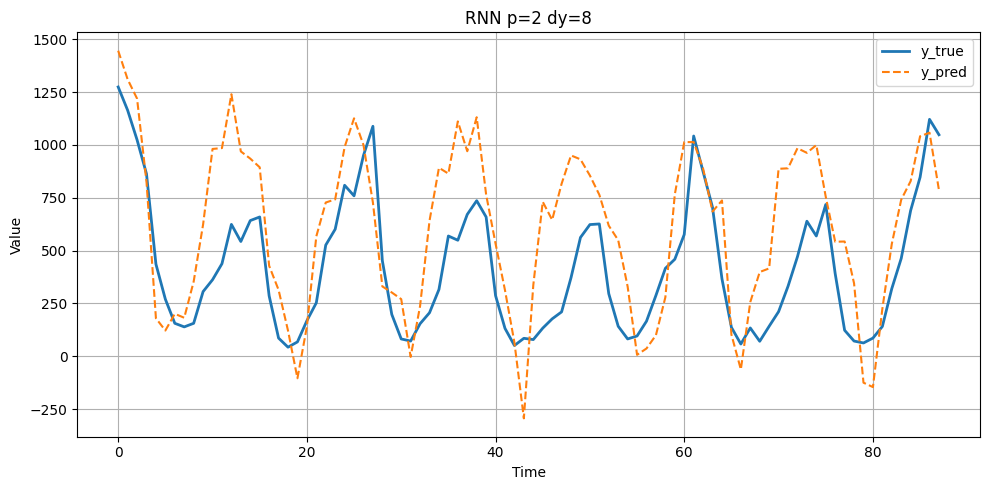

In [120]:
import matplotlib.pyplot as plt

def plot_pred_vs_true(y_true, y_pred, title="Prediction vs True"):
    plt.figure(figsize=(10, 5))

    plt.plot(y_true, label="y_true", linewidth=2)
    plt.plot(y_pred, label="y_pred", linestyle="--")

    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel("Value")

    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


# --- Sélection p=2, dy=8 ---
p_target = 2
dy_target = 8

found = False

for res in results:
    if res["p"] == p_target and res["dy"] == dy_target:
        plot_pred_vs_true(
            res["y_test"],
            res["y_pred"],
            f"RNN p={res['p']} dy={res['dy']}"
        )
        found = True
        break

if not found:
    print(f"Aucun résultat trouvé pour p={p_target}, dy={dy_target}")

### Analyse des performances du RNN

Les RNN (Recurrent Neural Networks) sont conçus pour traiter des données séquentielles en introduisant une mémoire via un état caché, défini par la relation $h_t = f(x_t, h_{t-1})$. Ils sont entraînés à l’aide du Backpropagation Through Time (BPTT), ce qui rend leur optimisation plus instable que celle des modèles feedforward (DNN). Dans ce contexte, leurs performances apparaissent globalement moins robustes.

Résultats observés :

- Pour $p=1$, les performances s’améliorent globalement lorsque la taille de la fenêtre $dy$ augmente. Un contexte temporel plus large permet au modèle de mieux exploiter l’information passée, bien que les résultats restent variables.

- Pour $p=2$, on observe une dégradation significative des performances, malgré l’utilisation de fenêtres temporelles plus larges.

- Pour $p=3$, la dégradation est encore plus marquée, accompagnée d’une forte instabilité des résultats.

**Interprétation théorique**

Ces observations s’expliquent par plusieurs caractéristiques propres aux RNN.

L’augmentation de $dy$ fournit davantage de contexte temporel, ce qui tend à réduire le biais et à améliorer la capacité du modèle à capturer la dynamique de la série. Toutefois, cette augmentation s’accompagne également d’une hausse de la variance, ce qui rend les performances plus instables.

Le modèle repose ici sur une approche directe : il prédit $y(t+p)$ à partir des valeurs passées, sans réinjecter ses propres prédictions. Ainsi, la dégradation des performances pour $p>1$ ne provient pas d’une accumulation d’erreurs, mais plutôt de la complexité accrue de la relation temporelle à apprendre et de l’augmentation de l’incertitude sur la cible lorsque l’horizon de prédiction s’allonge.

Par ailleurs, l’apprentissage via BPTT introduit des difficultés supplémentaires. Les gradients peuvent disparaître ou exploser, ce qui rend la convergence plus délicate et fortement dépendante du choix des hyperparamètres. Ce phénomène est particulièrement problématique lorsque les dépendances temporelles sont longues.

Enfin, dans ce cadre, les RNN n’apportent pas nécessairement un avantage structurel décisif. Les dépendances temporelles étant déjà explicitement introduites via les variables retardées ($y(t), y(t-1), \dots, y(t-dy)$), un modèle feedforward peut suffire à capturer la dynamique, tout en offrant une meilleure stabilité d’apprentissage.

Conclusion

Le RNN bénéficie d’un contexte temporel élargi lorsque $dy$ augmente, mais reste sensible à la variance et aux conditions d’entraînement. L’augmentation de l’horizon $p$ amplifie ces limitations en rendant la tâche plus complexe. Dans ce contexte, l’utilisation d’un RNN ne présente pas d’avantage clair par rapport à des modèles plus simples, qui peuvent offrir des performances comparables voire supérieures avec une meilleure robustesse.

In [125]:
import pandas as pd

data_optuna = []

for res in results_rnn:
    data_optuna.append({
        "p": res["p"],
        "dy": res["dy"],
        "MSE": res["mse"]
    })

df_optuna = pd.DataFrame(data_optuna)

pivot = df_optuna.pivot(index="dy", columns="p", values="MSE")

print("\n=== OPTUNA RNN Pivot Table (MSE) ===")
print(pivot.round(2))


=== OPTUNA RNN Pivot Table (MSE) ===
p          1          2          3
dy                                
7   82728.44  107797.35  151719.76
8   76246.11   89927.54  113918.00
9   46334.33   89574.31   65278.84
10  51215.69  136517.19   91842.00



### DNN vs RNN : 
Les réseaux de neurones feedforward (DNN) et récurrents (RNN) diffèrent principalement dans leur manière de traiter la dimension temporelle. Les DNN utilisent des valeurs retardées comme variables d’entrée indépendantes, ce qui revient à transformer la série temporelle en un problème statique de régression. À l’inverse, les RNN traitent les données de manière séquentielle et maintiennent un état caché évolutif, permettant de modéliser explicitement les dépendances temporelles entre les observations.

Cependant, dans des tâches de prédiction point-à-point basées sur une fenêtre glissante, les performances des DNN peuvent être comparables, voire supérieures, à celles des modèles récurrents. En effet, lorsque les valeurs passées sont directement fournies en entrée, le DNN dispose déjà de l’ensemble de l’information pertinente, ce qui limite l’apport d’une modélisation séquentielle.

Dans ce contexte, les résultats expérimentaux montrent que les DNN surpassent globalement les RNN. Cela s’explique par plusieurs facteurs. D’une part, la taille limitée du jeu de données (~500 observations) rend l’apprentissage des modèles récurrents instable, ceux-ci nécessitant généralement davantage de données pour généraliser correctement. 

Un autre point important concerne le format du problème. La prédiction est effectuée de manière directe à l’horizon $p$, sans boucle temporelle lors de l’inférence. Dans ce cadre, l’avantage des architectures récurrentes devient limité : leur capacité à modéliser une dynamique séquentielle profonde n’est pas réellement exploitée, puisqu’on leur fournit simplement une fenêtre de valeurs passées, de manière analogue à un réseau feedforward. Ainsi, la dépendance temporelle, essentiellement locale, est déjà correctement capturée par des variables retardées explicites, sans nécessiter de mécanisme de mémoire interne.

Enfin, les RNN souffrent de difficultés d’optimisation liées à la rétropropagation à travers le temps (BPTT), notamment la disparition ou l’explosion du gradient. Ces limitations réduisent leur capacité à exploiter efficacement les dépendances temporelles, en particulier lorsque les séquences sont courtes. Ainsi, bien que théoriquement adaptés aux données séquentielles, les RNN ne présentent pas ici d’avantage structurel par rapport aux DNN.

Remarque :  Au niveau des temps de calcul RNN est bien plus lent que les DNNs

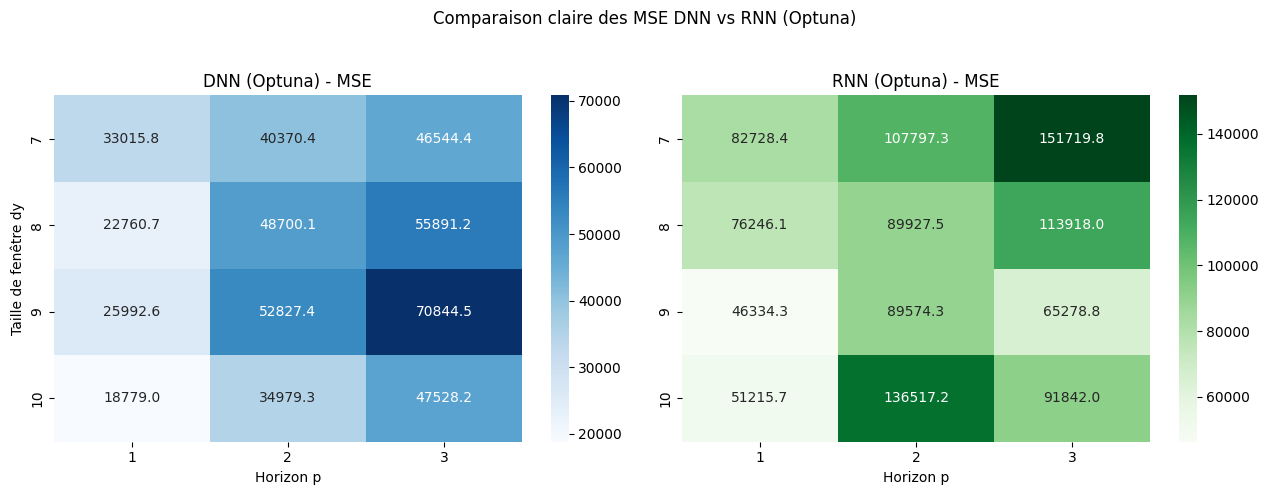

In [127]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- DNN ---
pivot_dnn = pd.DataFrame(df_results).pivot(
    index='dy',
    columns='p',
    values='mse_optuna'
)

# --- RNN (conversion depuis liste de dict) ---
df_rnn = pd.DataFrame(results_rnn)

pivot_rnn = df_rnn.pivot(
    index='dy',
    columns='p',
    values='mse'
)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(pivot_dnn, annot=True, fmt='.1f', cmap='Blues', ax=axes[0])
axes[0].set_title('DNN (Optuna) - MSE')
axes[0].set_xlabel('Horizon p')
axes[0].set_ylabel('Taille de fenêtre dy')

sns.heatmap(pivot_rnn, annot=True, fmt='.1f', cmap='Greens', ax=axes[1])
axes[1].set_title('RNN (Optuna) - MSE')
axes[1].set_xlabel('Horizon p')
axes[1].set_ylabel('')

plt.suptitle('Comparaison claire des MSE DNN vs RNN (Optuna)')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


### Mémoire Longue à Court Terme (LSTM)

Les LSTM (*Long Short-Term Memory*) constituent une amélioration des RNN, conçue pour atténuer les problèmes de *vanishing* et *exploding gradients*, et ainsi mieux capturer les dépendances temporelles de long terme. Ils introduisent un état de mémoire explicite $c_t$, distinct de l’état caché $h_t$, ce qui permet de maintenir un flux d’information plus stable au cours du temps.

L’idée centrale repose sur une mémoire contrôlée de manière adaptative. Cette mémoire évolue comme un flux continu, régulé par des mécanismes appelés *portes* (*gates*), qui agissent comme des filtres. Ces portes permettent au modèle de décider dynamiquement quelles informations doivent être conservées, oubliées ou intégrées à chaque instant.

Ce mécanisme rend les LSTM plus robustes que les RNN classiques lorsqu’il s’agit de modéliser des dépendances longues, en limitant la dégradation du signal au cours de la propagation temporelle.

<img src="1_laH0_xXEkFE0lKJu54gkFQ.webp" alt="LSTM schema" width="400">

### Formulation mathématique

$f_t = \sigma(W_f [h_{t-1}, x_t] + b_f)$

$i_t = \sigma(W_i [h_{t-1}, x_t] + b_i)$

$o_t = \sigma(W_o [h_{t-1}, x_t] + b_o)$

$\tilde{c}*t = \tanh(W_c [h*{t-1}, x_t] + b_c)$

**Mise à jour de la mémoire :**
$c_t = f_t \cdot c_{t-1} + i_t \cdot \tilde{c}_t$

**État caché :**
$h_t = o_t \cdot \tanh(c_t)$



### Intuition
La clé du LSTM est la mise à jour **additive** de la mémoire :

$c_t = f_t \cdot c_{t-1} + \text{nouvelle information}$

Si $f_t \approx 1$, l’information est conservée presque intacte. Cela stabilise la propagation du gradient et limite le *vanishing gradient*, contrairement aux RNN classiques basés sur des transformations répétées.


**Avantages :**

* Capture des dépendances longues
* Meilleure stabilité du gradient

**Limites :**

* Plus complexe (beaucoup de paramètres)
* Nécessite plus de données
* Peu pertinent si les retards sont déjà donnés en entrée (comme ici)

### Source

* Shi Yan, *Understanding LSTM and its diagrams*
* [https://blog.mlreview.com/understanding-lstm-and-its-diagrams-37e2f46f1714](https://blog.mlreview.com/understanding-lstm-and-its-diagrams-37e2f46f1714)


Pour le code, on garde lamême méthodologie que pour les RNNs : 

In [87]:
def build_lstm_model(input_shape, n_units):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(n_units, activation='tanh'),
        Dense(1)
    ])
    model.compile(optimizer='RMSprop', loss='mse')
    return model

In [88]:
def optimize_lstm_model(y, p, dy):

    X, T = prepare_rnn_dataset(y, dy, p)

    X_train = X[:320]
    y_train = T[:320]
    X_val   = X[320:400]
    y_val   = T[320:400]

    def objective(trial):

        tf.keras.backend.clear_session()

        n_units = trial.suggest_int("n_units", 8, 32)
        epochs = trial.suggest_int("epochs", 30, 60)
        patience = trial.suggest_int("patience", 5, 10)

        # Scaling
        x_scaler = StandardScaler()
        y_scaler = StandardScaler()

        X_train_shape = X_train.shape
        X_val_shape   = X_val.shape

        X_train_s = x_scaler.fit_transform(X_train.reshape(-1,1)).reshape(X_train_shape)
        X_val_s   = x_scaler.transform(X_val.reshape(-1,1)).reshape(X_val_shape)

        y_train_s = y_scaler.fit_transform(y_train)
        y_val_s   = y_scaler.transform(y_val)

        model = build_lstm_model((dy, 1), n_units)

        es = EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)

        model.fit(
            X_train_s, y_train_s,
            validation_data=(X_val_s, y_val_s),
            epochs=epochs,
            batch_size=4,
            verbose=0,
            callbacks=[es]
        )

        y_pred_scaled = model.predict(X_val_s, verbose=0)
        y_pred = y_scaler.inverse_transform(y_pred_scaled)

        return mean_squared_error(y_val, y_pred)

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=10)

    return study.best_params

In [89]:
def final_lstm_evaluation(y, p, dy, best_params):

    V, T = prepare_rnn_dataset(y, dy, p)

    # Split
    X_train = V[:400]
    y_train = T[:400]
    X_test  = V[400:]
    y_test  = T[400:]

    # Scaling
    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_train_shape = X_train.shape
    X_test_shape  = X_test.shape

    X_train = x_scaler.fit_transform(X_train.reshape(-1,1)).reshape(X_train_shape)
    X_test  = x_scaler.transform(X_test.reshape(-1,1)).reshape(X_test_shape)

    y_train = y_scaler.fit_transform(y_train)

    # Modèle
    model = build_lstm_model((dy, 1), best_params["n_units"])

    model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=best_params["epochs"],
        batch_size=4,
        callbacks=[EarlyStopping(patience=best_params["patience"], restore_best_weights=True)],
        verbose=0
    )

    # Prédiction
    y_pred_scaled = model.predict(X_test, verbose=0)
    y_pred = y_scaler.inverse_transform(y_pred_scaled)

    mse = mean_squared_error(y_test, y_pred)

    return mse, y_test, y_pred

In [90]:
def run_all_lstm_optuna(y):
    results = []

    for p in [1, 2, 3]:
        for dy in [7, 8, 9, 10]:

            print(f"\n=== LSTM p={p}, dy={dy} ===")

            best_params = optimize_lstm_model(y, p, dy)
            mse, y_test, y_pred = final_lstm_evaluation(y, p, dy, best_params)

            print(f"Best params: {best_params}")
            print(f"Test MSE (LSTM): {mse:.2f}")

            results.append({
                "p": p,
                "dy": dy,
                "mse": mse,
                "y_test": y_test,
                "y_pred": y_pred
            })

    return results

In [93]:
lstm_results = run_all_lstm_optuna(y)

df_lstm = pd.DataFrame([
    {"p": r["p"], "dy": r["dy"], "MSE": r["mse"]}
    for r in lstm_results
])

print("\n=== LSTM OPTUNA ===")
print(df_lstm.pivot(index="dy", columns="p", values="MSE").round(2))

[I 2026-04-26 13:20:04,810] A new study created in memory with name: no-name-49811f35-bfd4-4677-bc1b-1ceefa52e2c6



=== LSTM p=1, dy=7 ===


[I 2026-04-26 13:20:13,768] Trial 0 finished with value: 43285.46103412293 and parameters: {'n_units': 13, 'epochs': 45, 'patience': 10}. Best is trial 0 with value: 43285.46103412293.
[I 2026-04-26 13:20:21,003] Trial 1 finished with value: 74450.60669267134 and parameters: {'n_units': 18, 'epochs': 39, 'patience': 7}. Best is trial 0 with value: 43285.46103412293.
[I 2026-04-26 13:20:28,044] Trial 2 finished with value: 56445.37624091432 and parameters: {'n_units': 10, 'epochs': 33, 'patience': 9}. Best is trial 0 with value: 43285.46103412293.
[I 2026-04-26 13:20:35,593] Trial 3 finished with value: 50040.43150019315 and parameters: {'n_units': 17, 'epochs': 30, 'patience': 7}. Best is trial 0 with value: 43285.46103412293.
[I 2026-04-26 13:20:43,185] Trial 4 finished with value: 51547.98489822389 and parameters: {'n_units': 24, 'epochs': 34, 'patience': 5}. Best is trial 0 with value: 43285.46103412293.
[I 2026-04-26 13:20:49,585] Trial 5 finished with value: 49049.748299318075 and

Best params: {'n_units': 30, 'epochs': 50, 'patience': 8}
Test MSE (LSTM): 166215.21

=== LSTM p=1, dy=8 ===


[I 2026-04-26 13:21:31,143] Trial 0 finished with value: 60075.64624845417 and parameters: {'n_units': 27, 'epochs': 49, 'patience': 5}. Best is trial 0 with value: 60075.64624845417.
[I 2026-04-26 13:21:37,144] Trial 1 finished with value: 35557.01980413809 and parameters: {'n_units': 31, 'epochs': 48, 'patience': 6}. Best is trial 1 with value: 35557.01980413809.
[I 2026-04-26 13:21:43,922] Trial 2 finished with value: 34621.58995404593 and parameters: {'n_units': 32, 'epochs': 30, 'patience': 8}. Best is trial 2 with value: 34621.58995404593.
[I 2026-04-26 13:21:49,252] Trial 3 finished with value: 80008.14586344793 and parameters: {'n_units': 19, 'epochs': 37, 'patience': 5}. Best is trial 2 with value: 34621.58995404593.
[I 2026-04-26 13:21:55,618] Trial 4 finished with value: 43944.57078841509 and parameters: {'n_units': 25, 'epochs': 60, 'patience': 5}. Best is trial 2 with value: 34621.58995404593.
[I 2026-04-26 13:22:04,914] Trial 5 finished with value: 46649.58674080905 and p

...

Best params: {'n_units': 28, 'epochs': 37, 'patience': 5}
Test MSE (LSTM): 290974.07

=== LSTM p=3, dy=9 ===


[I 2026-04-26 13:33:19,895] Trial 0 finished with value: 87423.71198946354 and parameters: {'n_units': 21, 'epochs': 33, 'patience': 10}. Best is trial 0 with value: 87423.71198946354.
[I 2026-04-26 13:33:29,435] Trial 1 finished with value: 81993.4787678276 and parameters: {'n_units': 25, 'epochs': 58, 'patience': 8}. Best is trial 1 with value: 81993.4787678276.
[I 2026-04-26 13:33:36,775] Trial 2 finished with value: 85553.12645246704 and parameters: {'n_units': 23, 'epochs': 51, 'patience': 10}. Best is trial 1 with value: 81993.4787678276.
[I 2026-04-26 13:33:44,401] Trial 3 finished with value: 101028.45992555322 and parameters: {'n_units': 15, 'epochs': 30, 'patience': 8}. Best is trial 1 with value: 81993.4787678276.
[I 2026-04-26 13:33:50,958] Trial 4 finished with value: 93042.18675724234 and parameters: {'n_units': 19, 'epochs': 50, 'patience': 7}. Best is trial 1 with value: 81993.4787678276.
[I 2026-04-26 13:33:55,544] Trial 5 finished with value: 116973.64033663017 and pa

Best params: {'n_units': 25, 'epochs': 58, 'patience': 8}
Test MSE (LSTM): 191738.66

=== LSTM p=3, dy=10 ===


[I 2026-04-26 13:34:27,568] Trial 0 finished with value: 99581.90274991447 and parameters: {'n_units': 30, 'epochs': 42, 'patience': 6}. Best is trial 0 with value: 99581.90274991447.
[I 2026-04-26 13:34:31,544] Trial 1 finished with value: 93155.66156621091 and parameters: {'n_units': 22, 'epochs': 52, 'patience': 5}. Best is trial 1 with value: 93155.66156621091.
[I 2026-04-26 13:34:36,361] Trial 2 finished with value: 106648.16889347653 and parameters: {'n_units': 9, 'epochs': 49, 'patience': 8}. Best is trial 1 with value: 93155.66156621091.
[I 2026-04-26 13:34:40,718] Trial 3 finished with value: 86118.07049210506 and parameters: {'n_units': 30, 'epochs': 31, 'patience': 10}. Best is trial 3 with value: 86118.07049210506.
[I 2026-04-26 13:34:44,341] Trial 4 finished with value: 94607.13062338936 and parameters: {'n_units': 23, 'epochs': 53, 'patience': 6}. Best is trial 3 with value: 86118.07049210506.
[I 2026-04-26 13:34:50,552] Trial 5 finished with value: 81712.69009655333 and 

Best params: {'n_units': 25, 'epochs': 51, 'patience': 7}
Test MSE (LSTM): 165453.00

=== LSTM OPTUNA ===
p           1          2          3
dy                                 
7   166215.21  198211.66  271837.10
8    90716.88  162618.00  290974.07
9   144445.64  160795.99  191738.66
10   78805.26  108254.89  165453.00


## Analyse des performances des LSTM

Les résultats obtenus confirment globalement les tendances précédentes, tout en mettant en évidence le comportement instable du LSTM sur cette tâche.

Dans un premier temps, pour $p=1$, l’impact de la taille de la fenêtre $dy$ reste limité et irrégulier. Contrairement à ce qui pourrait être attendu, l’augmentation de $dy$ n’entraîne pas une amélioration systématique des performances. Certaines valeurs intermédiaires, comme $dy=8$ ou $dy=10$, donnent de meilleurs résultats, tandis que d’autres configurations restent moins performantes. Cela suggère l’existence d’un compromis entre quantité d’information utile et bruit introduit, en particulier dans un contexte de données limitées.

On remarque également un écart important entre validation et test pour plusieurs configurations. Ce phénomène traduit soit un surapprentissage, soit une mauvaise généralisation, lié à la fois à la faible taille du jeu de données et à la variance élevée des réseaux récurrents, mais aussi à une différence de distribution entre les données d’entraînement/validation et les données de test. Ce désalignement peut amplifier l’écart observé, même lorsque le modèle semble bien ajusté en validation.

Pour $p=2$, les performances deviennent nettement moins fiables. Le modèle a plus de difficulté à apprendre une dynamique robuste lorsque l’horizon de prédiction augmente. L’incertitude devient plus importante, et le LSTM ne parvient pas à exploiter efficacement les informations disponibles pour maintenir des prédictions cohérentes.

Pour $p=3$, cette tendance est encore plus marquée. Le modèle devient très instable et peine à généraliser. Même lorsque la validation semble correcte, les performances en test restent faibles, ce qui confirme une incapacité à capturer correctement les dépendances à plus long terme dans ce contexte.

Un point important est la forte variabilité entre les essais Optuna. Pour un même couple $(p, dy)$, les résultats peuvent varier significativement. Cela montre que le LSTM est très sensible à l’initialisation, aux hyperparamètres et au processus d’optimisation, ce qui complique son utilisation sur un petit jeu de données.

Au final, ces observations confirment que le LSTM n’est pas particulièrement adapté à cette tâche. Bien qu’il puisse exploiter un contexte plus large pour $p=1$, il reste globalement instable et difficile à généraliser.

Cela s’explique principalement par deux facteurs. D’une part, le manque de données ($\sim 500$ observations) limite fortement la capacité du modèle à apprendre des dépendances longues. D’autre part, la structure du problème rend l’utilisation du LSTM en grande partie redondante, puisque l’information temporelle est déjà fournie explicitement via les fenêtres glissantes.

Ainsi, dans ce contexte, un modèle plus simple comme un DNN apparaît plus pertinent : il est plus stable, plus robuste à l’entraînement, et exploite directement les informations disponibles sans complexité inutile.

### Conclusion

L’augmentation de la complexité du modèle ($\text{RNN} \rightarrow \text{LSTM}$) n’apporte pas de gain significatif et tend à introduire davantage de variance et d’instabilité. Dans ce contexte, il ne surpasse pas les RNN simples ni les réseaux feedforward, qui restent plus adaptés compte tenu de la taille des données et de la formulation du problème.

In [105]:
pivot_lstm = df_lstm.pivot_table(
    index="dy",
    columns="p",
    values="mse",
    aggfunc="mean"
).round(2)

print(pivot_lstm)

p           1          2          3
dy                                 
7   166215.21  198211.66  271837.10
8    90716.88  162618.00  290974.07
9   144445.64  160795.99  191738.66
10   78805.26  108254.89  165453.00


Ce graphique met clairement en évidence la faible qualité des prédictions avec LSTM pour $p=2$ et $dy=8$, contrairement au modèle DNN qui se montre nettement plus précis dans cette configuration.

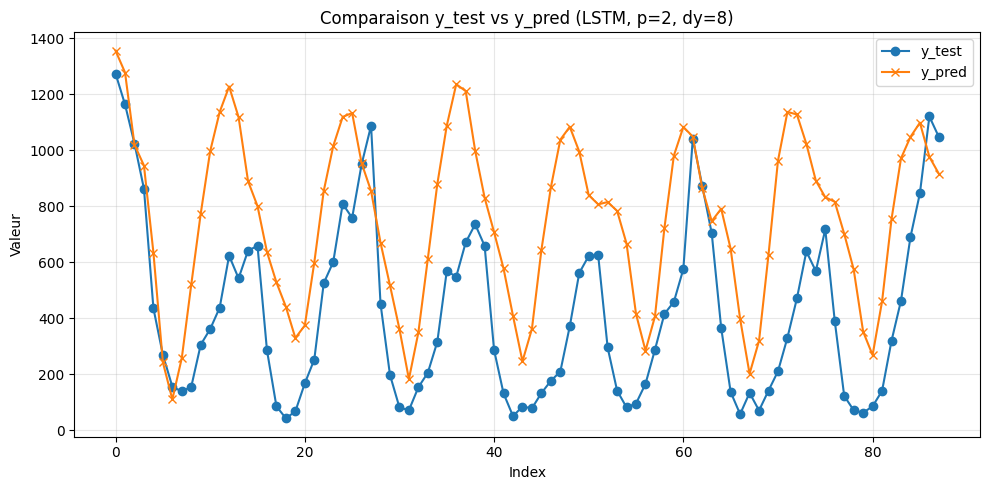

In [129]:
import matplotlib.pyplot as plt
import numpy as np

# Supposons que lstm_results est une liste de dictionnaires ou un DataFrame contenant les résultats pour différents (p, dy)
if 'lstm_results' not in globals():
    raise ValueError("La variable 'lstm_results' n'est pas définie.")

import pandas as pd
if isinstance(lstm_results, list):
    df_lstm = pd.DataFrame(lstm_results)
else:
    df_lstm = lstm_results.copy()

# Filtrer pour p=2 et dy=8
row = df_lstm[(df_lstm['p'] == 2) & (df_lstm['dy'] == 8)]
if row.empty:
    raise ValueError("Aucun résultat trouvé pour p=2 et dy=8 dans lstm_results.")

# On suppose que les colonnes sont 'y_test' et 'y_pred' (vecteurs ou listes)
y_test = row.iloc[0]['y_test']
y_pred = row.iloc[0]['y_pred']

plt.figure(figsize=(10, 5))
plt.plot(y_test, label='y_test', marker='o')
plt.plot(y_pred, label='y_pred', marker='x')
plt.title('Comparaison y_test vs y_pred (LSTM, p=2, dy=8)')
plt.xlabel('Index')
plt.ylabel('Valeur')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Gated Recurrent Unit (GRU)
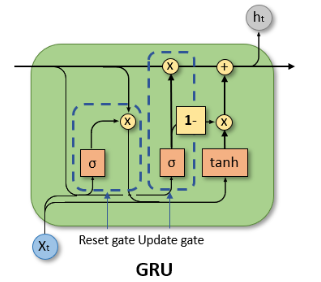


Les GRU (Gated Recurrent Unit) constituent une variante simplifiée des LSTM pour modéliser des données séquentielles.
Ils fusionnent les portes forget et input en une seule update gate, et utilisent une reset gate pour contrôler l’influence du passé.
Contrairement aux LSTM, ils ne possèdent pas de cellule mémoire séparée, ce qui réduit le nombre de paramètres et facilite l’entraînement.

#### Équations

$z_t = \sigma(W_z [h_{t-1}, x_t] + b_z)$

$r_t = \sigma(W_r [h_{t-1}, x_t] + b_r)$

$\tilde{h}t = \tanh(W_n [r_t \cdot h{t-1}, x_t] + b_n)$

$h_t = (1 - z_t)\tilde{h}t + z_t h{t-1}$

#### Idée clé
$r_t$ : contrôle l’oubli du passé (reset gate)
$z_t$ : contrôle la mise à jour de l’état (update gate)
$\tilde{h}_t$ : nouvelle information candidate
Le mécanisme de mise à jour est additif, ce qui permet un flux de gradient plus stable que dans les RNN classiques.

**Avantages :**
- Moins de paramètres $\Rightarrow$ entraînement plus rapide
- Bonne capacité à capturer les dépendances temporelles
- Plus stable que les RNN classiques

**Limite**
- Moins expressif que les LSTM pour modéliser des dépendances très longues

#### Conclusion
Le GRU constitue un compromis efficace entre simplicité, vitesse et performance.
Dans de nombreux cas pratiques, il offre des performances comparables aux LSTM tout en étant plus facile à entraîner, notamment lorsque les données sont limitées.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Supposons que gru_results est une liste de dictionnaires ou un DataFrame contenant les résultats pour différents (p, dy)
if 'gru_results' not in globals():
    raise ValueError("La variable 'gru_results' n'est pas définie.")

if isinstance(gru_results, list):
    df_gru = pd.DataFrame(gru_results)
else:
    df_gru = gru_results.copy()

# Filtrer pour p=2 et dy=8
row = df_gru[(df_gru['p'] == 2) & (df_gru['dy'] == 8)]
if row.empty:
    raise ValueError("Aucun résultat trouvé pour p=2 et dy=8 dans gru_results.")

# On suppose que les colonnes sont 'y_test' et 'y_pred' (vecteurs ou listes)
y_test = row.iloc[0]['y_test']
y_pred = row.iloc[0]['y_pred']

plt.figure(figsize=(10, 5))
plt.plot(y_test, label='y_test', marker='o')
plt.plot(y_pred, label='y_pred', marker='x')
plt.title('Comparaison y_test vs y_pred (GRU, p=2, dy=8)')
plt.xlabel('Index')
plt.ylabel('Valeur')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [108]:
def optimize_gru_model(y, p, dy):

    X, T = prepare_rnn_dataset(y, dy, p)

    # split train / validation
    X_train, y_train = X[:320], T[:320]
    X_val, y_val     = X[320:400], T[320:400]

    def objective(trial):

        tf.keras.backend.clear_session()

        # Hyperparamètres
        n_units  = trial.suggest_int("n_units", 8, 32)
        n_layers = trial.suggest_int("n_layers", 1, 2)
        epochs   = trial.suggest_int("epochs", 30, 60)
        patience = trial.suggest_int("patience", 5, 10)

        # Scaling (correct pour données 3D)
        x_scaler = StandardScaler()
        y_scaler = StandardScaler()

        X_train_shape = X_train.shape
        X_val_shape   = X_val.shape

        X_train_s = x_scaler.fit_transform(X_train.reshape(-1,1)).reshape(X_train_shape)
        X_val_s   = x_scaler.transform(X_val.reshape(-1,1)).reshape(X_val_shape)

        y_train_s = y_scaler.fit_transform(y_train)
        y_val_s   = y_scaler.transform(y_val)

        # Modèle
        model = build_gru_model((dy, 1), n_units, n_layers)

        es = EarlyStopping(
            monitor='val_loss',
            patience=patience,
            restore_best_weights=True
        )

        model.fit(
            X_train_s, y_train_s,
            validation_data=(X_val_s, y_val_s),
            epochs=epochs,
            batch_size=4,
            verbose=0,
            callbacks=[es]
        )

        # Prédiction validation
        y_pred_s = model.predict(X_val_s, verbose=0)
        y_pred = y_scaler.inverse_transform(y_pred_s)

        return mean_squared_error(y_val, y_pred)

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=10)

    return study.best_params

In [109]:
def final_gru_evaluation(y, p, dy, best_params):
    X, T = prepare_rnn_dataset(y, dy, p)

    X_train, y_train = X[:400], T[:400]
    X_test, y_test   = X[400:], T[400:]

    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_train_s = x_scaler.fit_transform(X_train.reshape(-1,1)).reshape(X_train.shape)
    X_test_s  = x_scaler.transform(X_test.reshape(-1,1)).reshape(X_test.shape)

    y_train_s = y_scaler.fit_transform(y_train)

    model = build_gru_model(
        (dy,1),
        best_params["n_units"],
        best_params["n_layers"]
    )

    model.fit(
        X_train_s, y_train_s,
        validation_split=0.2,
        epochs=best_params["epochs"],
        batch_size=4,
        callbacks=[EarlyStopping(patience=best_params["patience"], restore_best_weights=True)],
        verbose=0
    )
    # PREDICTIONS
    y_pred_scaled = model.predict(X_test_s, verbose=0)
    y_pred_gru = y_scaler.inverse_transform(y_pred_scaled)

    mse = mean_squared_error(y_test, y_pred_gru)

    return mse, y_test, y_pred_gru

In [110]:
def run_all_gru(y):
    results = []

    for p in [1,2,3]:
        for dy in [7,8,9,10]:

            print(f"\n=== GRU p={p}, dy={dy} ===")

            best_params = optimize_gru_model(y, p, dy)
            mse, y_true, y_pred = final_gru_evaluation(y, p, dy, best_params)

            print(f"Best params: {best_params}")
            print(f"Test MSE (GRU): {mse:.2f}")

            results.append({
                "p": p,
                "dy": dy,
                "mse": mse,
                "y_test": y_true,
                "y_pred": y_pred
            })

    return results

### Résultats : 

Les résultats montrent que le **GRU** se situe clairement **entre le RNN et le LSTM**, sans surpasser les modèles plus simples.
Pour $p=1$, le GRU obtient ses meilleurs résultats lorsque $dy$ est élevé, ce qui confirme qu’il exploite mieux le contexte temporel. Toutefois, ses performances restent **moins bonnes que celles du DNN optimisé**, et comparables voire légèrement meilleures que le RNN.
Lorsque $p>1$, la dégradation est nette ($p=2$, $p=3$), comme pour les autres modèles. Cela s’explique par la **complexité croissante de la relation $y(t) \rightarrow y(t+p)$**, indépendamment de l’architecture.

### Lecture théorique
Le comportement observé est cohérent avec la structure du GRU :
* Plus simple que le **LSTM** (moins de paramètres, pas de cellule $c_t$)
* Plus structuré que le **RNN** (gates $\Rightarrow$ meilleure gestion de la mémoire)

Donc :
* **RNN** → trop instable (pas de contrôle mémoire)
* **LSTM** → trop complexe (surparamétré pour peu de données)
* **GRU** → compromis (moins de variance que LSTM, plus stable que RNN)

Mais dans ce problème :
* la dépendance temporelle est déjà donnée via $(y(t), \dots, y(t-dy))$
* donc l’avantage des architectures récurrentes est limité

### Conclusion
Le GRU est **plus stable et plus simple que le LSTM**, ce qui se reflète dans les résultats, mais cela ne suffit pas à dépasser un **DNN**.
Dans ce contexte :
* GRU = bon compromis théorique
* DNN = meilleur choix pratique (plus simple, plus robuste)
*Remarque* : Les GRU sont bien plus rapide à optimiser vis à vis des LSTMs, ce qui montre bien leurs propriétés moins profonde également.

In [111]:
# RUN
gru_results = run_all_gru(y)

gru_df = pd.DataFrame([
    {"p": r["p"], "dy": r["dy"], "MSE": r["mse"]}
    for r in gru_results
])

print("\n=== GRU OPTUNA ===")
print(gru_df.pivot(index="dy", columns="p", values="MSE").round(2))

[I 2026-04-26 13:41:15,844] A new study created in memory with name: no-name-dbf80c78-30e7-469f-a321-509561e0d182



=== GRU p=1, dy=7 ===


[I 2026-04-26 13:41:24,050] Trial 0 finished with value: 51016.14525506322 and parameters: {'n_units': 24, 'n_layers': 1, 'epochs': 57, 'patience': 7}. Best is trial 0 with value: 51016.14525506322.
[I 2026-04-26 13:41:30,400] Trial 1 finished with value: 54298.151983750075 and parameters: {'n_units': 16, 'n_layers': 1, 'epochs': 43, 'patience': 7}. Best is trial 0 with value: 51016.14525506322.
[I 2026-04-26 13:41:38,056] Trial 2 finished with value: 48283.205909621276 and parameters: {'n_units': 22, 'n_layers': 1, 'epochs': 55, 'patience': 7}. Best is trial 2 with value: 48283.205909621276.
[I 2026-04-26 13:41:47,502] Trial 3 finished with value: 70749.00722744182 and parameters: {'n_units': 9, 'n_layers': 2, 'epochs': 53, 'patience': 8}. Best is trial 2 with value: 48283.205909621276.
[I 2026-04-26 13:41:56,042] Trial 4 finished with value: 62551.809424151994 and parameters: {'n_units': 9, 'n_layers': 2, 'epochs': 44, 'patience': 5}. Best is trial 2 with value: 48283.205909621276.
[

Best params: {'n_units': 25, 'n_layers': 1, 'epochs': 39, 'patience': 6}
Test MSE (GRU): 164752.08

=== GRU p=1, dy=8 ===


[I 2026-04-26 13:42:51,369] Trial 0 finished with value: 52432.55544293862 and parameters: {'n_units': 26, 'n_layers': 1, 'epochs': 32, 'patience': 8}. Best is trial 0 with value: 52432.55544293862.
[I 2026-04-26 13:43:05,652] Trial 1 finished with value: 43332.83572174689 and parameters: {'n_units': 10, 'n_layers': 2, 'epochs': 58, 'patience': 10}. Best is trial 1 with value: 43332.83572174689.
[I 2026-04-26 13:43:13,692] Trial 2 finished with value: 63332.482453003875 and parameters: {'n_units': 16, 'n_layers': 2, 'epochs': 39, 'patience': 5}. Best is trial 1 with value: 43332.83572174689.
[I 2026-04-26 13:43:20,552] Trial 3 finished with value: 46354.26913963464 and parameters: {'n_units': 32, 'n_layers': 1, 'epochs': 32, 'patience': 8}. Best is trial 1 with value: 43332.83572174689.
[I 2026-04-26 13:43:28,941] Trial 4 finished with value: 35038.80541059796 and parameters: {'n_units': 18, 'n_layers': 2, 'epochs': 35, 'patience': 7}. Best is trial 4 with value: 35038.80541059796.
[I 

...

Best params: {'n_units': 25, 'n_layers': 2, 'epochs': 55, 'patience': 8}
Test MSE (GRU): 192118.88

=== GRU p=3, dy=9 ===


[I 2026-04-26 13:58:21,703] Trial 0 finished with value: 68279.56063250949 and parameters: {'n_units': 29, 'n_layers': 1, 'epochs': 32, 'patience': 7}. Best is trial 0 with value: 68279.56063250949.
[I 2026-04-26 13:58:29,237] Trial 1 finished with value: 83932.58644051665 and parameters: {'n_units': 29, 'n_layers': 2, 'epochs': 46, 'patience': 6}. Best is trial 0 with value: 68279.56063250949.
[I 2026-04-26 13:58:37,020] Trial 2 finished with value: 68650.38335058007 and parameters: {'n_units': 31, 'n_layers': 2, 'epochs': 57, 'patience': 9}. Best is trial 0 with value: 68279.56063250949.
[I 2026-04-26 13:58:43,824] Trial 3 finished with value: 53375.2588436028 and parameters: {'n_units': 29, 'n_layers': 2, 'epochs': 55, 'patience': 6}. Best is trial 3 with value: 53375.2588436028.
[I 2026-04-26 13:58:50,128] Trial 4 finished with value: 75563.90254056324 and parameters: {'n_units': 23, 'n_layers': 1, 'epochs': 60, 'patience': 10}. Best is trial 3 with value: 53375.2588436028.
[I 2026

Best params: {'n_units': 29, 'n_layers': 2, 'epochs': 55, 'patience': 6}
Test MSE (GRU): 195687.58

=== GRU p=3, dy=10 ===


[I 2026-04-26 13:59:51,905] Trial 0 finished with value: 80006.60005855131 and parameters: {'n_units': 15, 'n_layers': 2, 'epochs': 45, 'patience': 7}. Best is trial 0 with value: 80006.60005855131.
[I 2026-04-26 13:59:59,386] Trial 1 finished with value: 85588.5728925971 and parameters: {'n_units': 24, 'n_layers': 2, 'epochs': 50, 'patience': 9}. Best is trial 0 with value: 80006.60005855131.
[I 2026-04-26 14:00:07,419] Trial 2 finished with value: 61970.134283831125 and parameters: {'n_units': 29, 'n_layers': 2, 'epochs': 39, 'patience': 7}. Best is trial 2 with value: 61970.134283831125.
[I 2026-04-26 14:00:15,702] Trial 3 finished with value: 73121.60918765591 and parameters: {'n_units': 15, 'n_layers': 1, 'epochs': 34, 'patience': 8}. Best is trial 2 with value: 61970.134283831125.
[I 2026-04-26 14:00:26,465] Trial 4 finished with value: 85462.9253388682 and parameters: {'n_units': 9, 'n_layers': 1, 'epochs': 44, 'patience': 7}. Best is trial 2 with value: 61970.134283831125.
[I 2

Best params: {'n_units': 29, 'n_layers': 2, 'epochs': 39, 'patience': 7}
Test MSE (GRU): 193141.33

=== GRU OPTUNA ===
p           1          2          3
dy                                 
7   164752.08  347404.42  243302.16
8   146364.91  129833.73  192118.88
9    84291.53  129885.57  195687.58
10   75590.74  148351.67  193141.33


In [114]:
print(gru_df.pivot(index="dy", columns="p", values="MSE").round(2))

p           1          2          3
dy                                 
7   164752.08  347404.42  243302.16
8   146364.91  129833.73  192118.88
9    84291.53  129885.57  195687.58
10   75590.74  148351.67  193141.33


Le modèle GRU capture globalement la périodicité mais présente un décalage d’amplitude et de phase, entraînant des erreurs importantes sur les pics et creux.


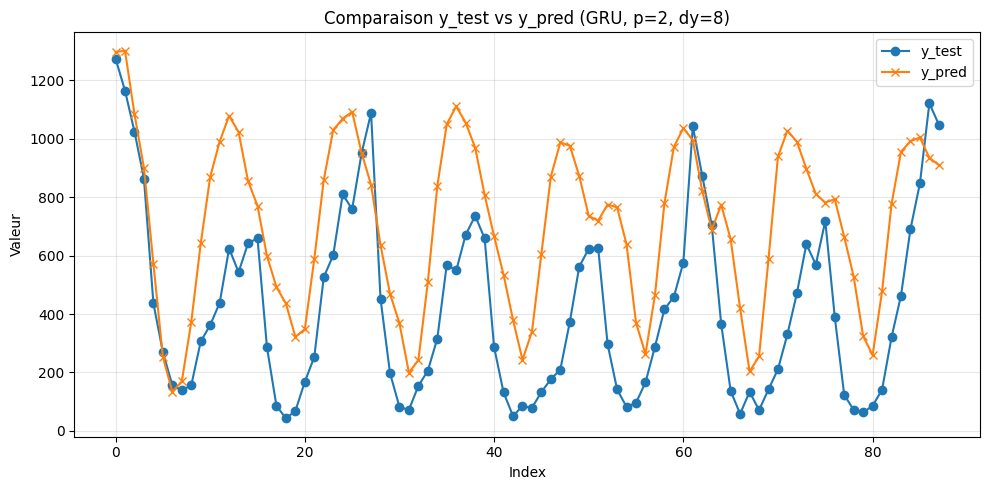

In [130]:
import matplotlib.pyplot as plt
import numpy as np

# Supposons que gru_results est une liste de dictionnaires ou un DataFrame contenant les résultats pour différents (p, dy)
if 'gru_results' not in globals():
    raise ValueError("La variable 'gru_results' n'est pas définie.")

import pandas as pd
if isinstance(gru_results, list):
    df_gru = pd.DataFrame(gru_results)
else:
    df_gru = gru_results.copy()

# Filtrer pour p=2 et dy=8
row = df_gru[(df_gru['p'] == 2) & (df_gru['dy'] == 8)]
if row.empty:
    raise ValueError("Aucun résultat trouvé pour p=2 et dy=8 dans gru_results.")

# On suppose que les colonnes sont 'y_test' et 'y_pred' (vecteurs ou listes)
y_test = row.iloc[0]['y_test']
y_pred = row.iloc[0]['y_pred']

plt.figure(figsize=(10, 5))
plt.plot(y_test, label='y_test', marker='o')
plt.plot(y_pred, label='y_pred', marker='x')
plt.title('Comparaison y_test vs y_pred (GRU, p=2, dy=8)')
plt.xlabel('Index')
plt.ylabel('Valeur')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Conclusion Final 
### Modèle Feed-Forward vs Récurent : 
 
- Les modèles feed-forward (DNN) apparaissent mieux adaptés à ce problème : ils capturent efficacement les dépendances locales via des variables retardées explicites, tout en restant simples et stables à entraîner.
- Les architectures récurrentes (RNN, LSTM, GRU) ne montrent pas d’amélioration significative, en raison d’un déséquilibre entre leur complexité et la taille limitée du jeu de données (~500 observations), ce qui induit une forte variance et des difficultés de convergence.
- Le format du problème joue un rôle déterminant : la prédiction est réalisée directement à l’horizon $p$, sans boucle temporelle lors de l’inférence. Dans ce cadre, la capacité des RNN à modéliser une dynamique séquentielle profonde n’est pas exploitée, et ils se comportent essentiellement comme des modèles à fenêtre fixe, similaires à un DNN.
- La structure du signal est relativement simple (dépendances locales + composante saisonnière). Elle ne nécessite pas de mémoire interne complexe, et peut être modélisée efficacement avec des approches plus directes.
- Les modèles récurrents restent sensibles aux conditions d’apprentissage (initialisation, hyperparamètres, scaling) et aux problèmes d’optimisation, ce qui accentue leur instabilité dans ce contexte.

En pratique, un modèle feed-forward correctement optimisé (par exemple via Optuna) offre un meilleur compromis biais/variance, une plus grande robustesse, et des performances supérieures sur ce type de série temporelle.

## Comparaisons des 4 modèles : 
Pour $p=1$, les performances sont globalement les meilleures. Le RNN et le DNN dominent clairement, avec des erreurs plus faibles et relativement stables selon $dy$, tandis que LSTM et GRU restent moins performants et plus variables.

Pour $p=2$, une dégradation nette apparaît pour tous les modèles. Le DNN et le RNN restent les plus compétitifs, mais l’écart avec LSTM et surtout GRU devient important, ces derniers montrant une forte instabilité et des erreurs élevées pour certaines configurations (notamment $dy=7$).

Pour $p=3$, la difficulté du problème est encore plus marquée. Les erreurs augmentent pour tous les modèles, mais DNN et RNN conservent les meilleures performances relatives. Les modèles plus complexes (LSTM, GRU) deviennent globalement moins fiables, avec des erreurs élevées et une forte variabilité selon $dy$.

Globalement, on observe que l’augmentation de l’horizon $p$ dégrade les performances, et que les modèles simples (DNN, RNN) restent les plus adaptés dans ce contexte, tandis que les modèles récurrents plus complexes n’apportent pas de gain et introduisent davantage d’instabilité.

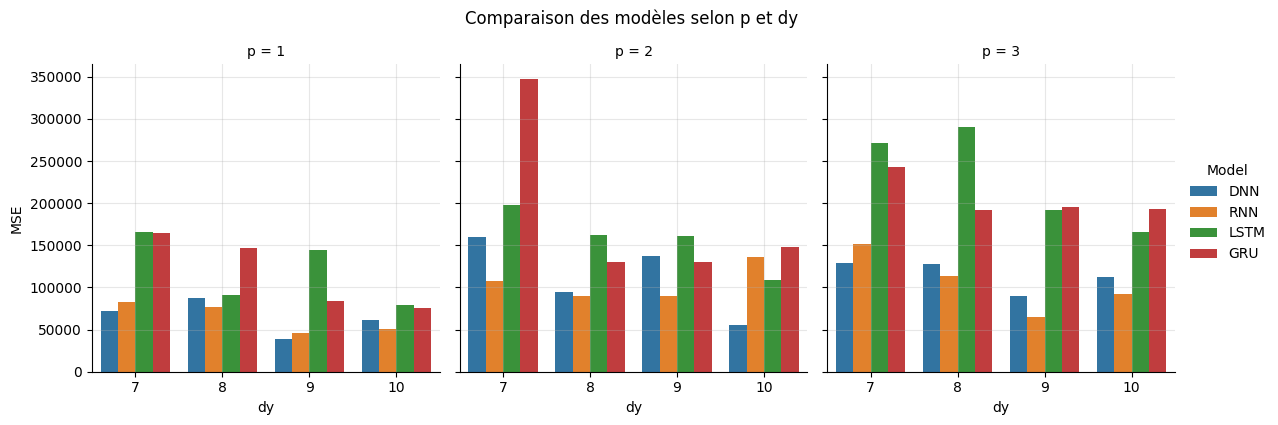

In [ ]:
data = []

for r in results:
    data.append({
        "Model": "DNN",
        "p": r["p"],
        "dy": r["dy"],
        "MSE": r["mse"]
    })

# --- RNN ---
for r in results_rnn:
    data.append({
        "Model": "RNN",
        "p": r["p"],
        "dy": r["dy"],
        "MSE": r["mse"]
    })

# --- LSTM ---
for r in lstm_results:
    data.append({
        "Model": "LSTM",
        "p": r["p"],
        "dy": r["dy"],
        "MSE": r["mse"]
    })

# --- GRU ---
for r in gru_results:
    data.append({
        "Model": "GRU",
        "p": r["p"],
        "dy": r["dy"],
        "MSE": r["mse"]
    })

df = pd.DataFrame(data)

# --- Plot seaborn ---

g = sns.catplot(
    data=df,
    x="dy",
    y="MSE",
    hue="Model",
    col="p",
    kind="bar",
    height=4,
    aspect=1
)

g.fig.suptitle("Comparaison des modèles selon p et dy", y=1.05)

for ax in g.axes.flat:
    ax.grid(alpha=0.3)

plt.show()



### Bonnus Idée :

Il serait également pertinent d’analyser la présence éventuelle de cycles dans la série temporelle. En effet, l’horizon de prédiction p n’a pas la même signification selon la périodicité réelle des données. Si la série possède un cycle court, par exemple hebdomadaire ou mensuel, certains horizons peuvent être naturellement plus faciles à prédire que d’autres. À l’inverse, si la dynamique principale est annuelle ou saisonnière, une prédiction à court horizon comme p=1, p=2 ou p=3 peut ne pas suffire à capturer cette structure globale.

Ainsi, la dégradation des performances lorsque p augmente ne doit pas seulement être interprétée comme une difficulté propre au modèle. Elle peut aussi venir d’un mauvais alignement entre l’horizon de prédiction choisi, la fenêtre temporelle dy et les cycles présents dans la série. Une analyse par autocorrélation ou par transformée de Fourier permettrait donc de vérifier si des périodicités importantes existent dans les données.


Pour cela on va utiliser l’autocorrélation permet de mesurer la corrélation entre une série temporelle et une version décalée d’elle-même.
Si la série présente une périodicité de période $T$, alors l’autocorrélation sera élevée pour un décalage $lag = T$.

Mathématiquement, l’autocorrélation pour un retard $k$ est donnée par :

$$\rho(k) = \frac{\mathbb{E}[(y_t - \mu)(y_{t-k} - \mu)]}{\sigma^2}$$

où $\mu$ est la moyenne et $\sigma^2$ la variance de la série.

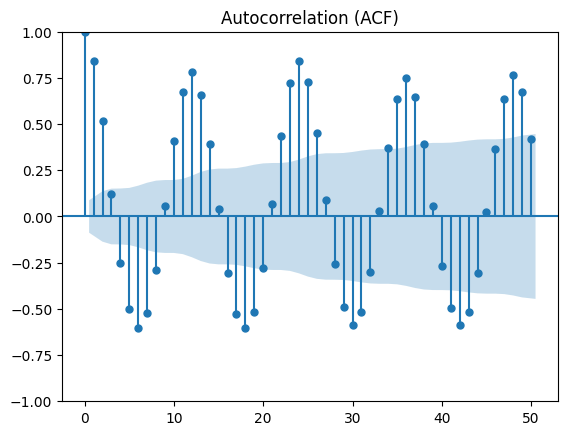

In [112]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(y, lags=50)
plt.title("Autocorrelation (ACF)")
plt.show()

L’analyse ACF met en évidence une saisonnalité marquée de période $\approx 12$. Or, les valeurs de $dy$ utilisées ($7 \leq dy \leq 10$) ne permettent pas de couvrir un cycle complet. Cela limite la capacité du modèle à capturer la dynamique globale de la série et peut expliquer une partie de la dégradation des performances, notamment pour $p>1$.

## Implémentation de la BPTT :
Backpropagation Through Time (BPTT) est un algorithme d’entraînement utilisé pour les réseaux de neurones récurrents (RNN). Il adapte l’algorithme de rétropropagation du gradient standard pour gérer la nature séquentielle et les dépendances temporelles inhérentes aux données traitées par ces réseaux. Son principe fondamental consiste à « dérouler » le réseau récurrent dans le temps, le transformant conceptuellement en un réseau de neurones profond multicouche (feedforward) où chaque couche représente une étape temporelle distincte. La rétropropagation classique est ensuite appliquée sur cette structure déroulée pour calculer les gradients et ajuster les poids du réseau.

### Backpropagation Through Time (BPTT)

On considère un RNN entraîné en minimisant une perte quadratique de la forme $ \mathcal{L} = (\hat{y} - y)^2 $. La rétropropagation dans le temps consiste à propager le gradient de cette perte à travers toutes les dépendances temporelles du modèle.

Dans un premier temps, on dérive la perte par rapport à la sortie du modèle : $ \frac{\partial \mathcal{L}}{\partial \hat{y}} = 2(\hat{y} - y) $. Ce gradient est ensuite propagé vers le dernier état caché via la matrice de sortie, ce qui donne $ \delta_{dy} = W_{hy}^T \frac{\partial \mathcal{L}}{\partial \hat{y}} $.

La dynamique interne du RNN repose sur la relation $ h_t = \tanh(W_{xh} x_t + W_{hh} h_{t-1} + b_h) $. La rétropropagation consiste donc à remonter dans le temps en appliquant la règle de chaîne. À chaque pas, le gradient vérifie la relation récursive $ \delta_t = (W_{hh}^T \delta_{t+1}) \odot (1 - h_t^2) $, où le terme $(1 - h_t^2)$ provient de la dérivée de la fonction $\tanh$.

Les gradients des paramètres s’obtiennent alors en accumulant les contributions sur toute la séquence : les termes associés à $W_{xh}$ dépendent des produits $\delta_t x_t^T$, ceux de $W_{hh}$ des produits $\delta_t h_{t-1}^T$, et le biais correspond à la somme des $\delta_t$.

Un point central de cette analyse est le comportement des gradients au cours du temps. En développant la relation de récurrence, on observe que le gradient en $t$ dépend d’un produit de matrices du type $(W_{hh}^T)^k$. Ce terme contrôle entièrement la stabilité de l’apprentissage.

Si le rayon spectral de $W_{hh}$ est strictement inférieur à 1, alors ces produits tendent vers zéro lorsque $k$ augmente. Le gradient s’annule progressivement, ce qui empêche le modèle d’apprendre des dépendances longues : c’est le phénomène de vanishing gradient. À l’inverse, si ce rayon spectral est supérieur à 1, les produits divergent et le gradient explose, rendant l’entraînement instable : on parle alors d’exploding gradient.

Dans la pratique, on introduit des techniques comme le gradient clipping, qui consiste à borner les gradients $g \leftarrow \text{clip}(g, -c, c)$ afin de limiter les mises à jour trop importantes. Cette technique stabilise l’entraînement, mais ne résout pas le problème fondamental de la mémoire à long terme.

C’est précisément cette limitation structurelle des RNN simples qui a motivé l’introduction d’architectures comme les LSTM ou les GRU, conçues pour contrôler explicitement la propagation de l’information et des gradients dans le temps.

In [116]:
# RNN manuel avec BPTT - uniquement NumPy
# Test pour p=1, dy=10

import numpy as np

p_bptt = 1
dy_bptt = 10

def prepare_rnn_numpy(y, p, dy):
    X, T = [], []
    for i in range(dy, len(y) - p):
        X.append(y[i-dy:i])
        T.append(y[i+p])
    return np.array(X).reshape(-1, dy, 1), np.array(T).reshape(-1, 1)

def mse_np(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def mae_np(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def train_rnn_bptt_numpy(
    y,
    p=1,
    dy=10,
    n_hidden=27,
    epochs=34,
    lr=0.001,
    clip_value=1.0,
    seed=42
):
    np.random.seed(seed)

    X, T = prepare_rnn_numpy(y, p, dy)

    X_train = X[:400]
    y_train = T[:400]
    X_test = X[400:]
    y_test = T[400:]

    x_mean = X_train.mean()
    x_std = X_train.std() + 1e-8
    y_mean = y_train.mean()
    y_std = y_train.std() + 1e-8

    X_train_s = (X_train - x_mean) / x_std
    X_test_s = (X_test - x_mean) / x_std
    y_train_s = (y_train - y_mean) / y_std

    Wxh = np.random.randn(n_hidden, 1) * 0.01
    Whh = np.random.randn(n_hidden, n_hidden) * 0.01
    Why = np.random.randn(1, n_hidden) * 0.01

    bh = np.zeros((n_hidden, 1))
    by = np.zeros((1, 1))

    losses = []

    for epoch in range(epochs):
        epoch_loss = 0.0

        for i in range(len(X_train_s)):
            x_seq = X_train_s[i]
            target = y_train_s[i].reshape(1, 1)

            hs = []
            h_prev = np.zeros((n_hidden, 1))

            # Forward pass
            for t in range(dy):
                x_t = x_seq[t].reshape(1, 1)
                h_t = np.tanh(Wxh @ x_t + Whh @ h_prev + bh)
                hs.append(h_t)
                h_prev = h_t

            y_hat = Why @ hs[-1] + by
            loss = np.mean((y_hat - target) ** 2)
            epoch_loss += loss

            # Backpropagation Through Time
            dWxh = np.zeros_like(Wxh)
            dWhh = np.zeros_like(Whh)
            dWhy = np.zeros_like(Why)
            dbh = np.zeros_like(bh)
            dby = np.zeros_like(by)

            dy_hat = 2 * (y_hat - target)

            dWhy += dy_hat @ hs[-1].T
            dby += dy_hat

            dh_next = Why.T @ dy_hat

            for t in reversed(range(dy)):
                h_t = hs[t]
                h_prev = hs[t-1] if t > 0 else np.zeros((n_hidden, 1))
                x_t = x_seq[t].reshape(1, 1)

                dtanh = dh_next * (1 - h_t ** 2)

                dWxh += dtanh @ x_t.T
                dWhh += dtanh @ h_prev.T
                dbh += dtanh

                dh_next = Whh.T @ dtanh

            for grad in [dWxh, dWhh, dWhy, dbh, dby]:
                np.clip(grad, -clip_value, clip_value, out=grad)

            Wxh -= lr * dWxh
            Whh -= lr * dWhh
            Why -= lr * dWhy
            bh -= lr * dbh
            by -= lr * dby

        losses.append(epoch_loss / len(X_train_s))

    y_pred_s = []

    for i in range(len(X_test_s)):
        x_seq = X_test_s[i]
        h_prev = np.zeros((n_hidden, 1))

        for t in range(dy):
            x_t = x_seq[t].reshape(1, 1)
            h_prev = np.tanh(Wxh @ x_t + Whh @ h_prev + bh)

        pred_s = Why @ h_prev + by
        y_pred_s.append(pred_s.item())

    y_pred_s = np.array(y_pred_s).reshape(-1, 1)
    y_pred = y_pred_s * y_std + y_mean

    mse = mse_np(y_test, y_pred)
    mae = mae_np(y_test, y_pred)

    return {
        "y_test": y_test,
        "y_pred": y_pred,
        "mse": mse,
        "mae": mae,
        "losses": np.array(losses),
        "params": {
            "Wxh": Wxh,
            "Whh": Whh,
            "Why": Why,
            "bh": bh,
            "by": by
        }
    }

result_bptt = train_rnn_bptt_numpy(
    y,
    p=p_bptt,
    dy=dy_bptt,
    n_hidden=27,
    epochs=34,
    lr=0.001
)

print("=== RNN manuel BPTT NumPy ===")
print("p =", p_bptt)
print("dy =", dy_bptt)
print("MSE =", round(result_bptt["mse"], 2))
print("MAE =", round(result_bptt["mae"], 2))

if "results_rnn" in globals():
    for p, dy, mse in results_rnn:
        if p == p_bptt and dy == dy_bptt:
            print("MSE RNN Keras deja calcule =", round(mse, 2))

print("\nPremieres predictions :")
print("index | y_test | y_pred")

y_test_flat = result_bptt["y_test"].ravel()
y_pred_flat = result_bptt["y_pred"].ravel()

for i in range(min(10, len(y_test_flat))):
    print(
        i,
        "|",
        round(float(y_test_flat[i]), 2),
        "|",
        round(float(y_pred_flat[i]), 2)
    )

print("\nDernieres pertes d'entrainement :")
print(result_bptt["losses"][-10:])


=== RNN manuel BPTT NumPy ===
p = 1
dy = 10
MSE = 150163.34
MAE = 343.93

Premieres predictions :
index | y_test | y_pred
0 | 1164.0 | 1102.32
1 | 1024.0 | 1281.4
2 | 863.0 | 866.39
3 | 436.0 | 572.69
4 | 270.0 | 410.28
5 | 156.0 | 87.98
6 | 139.0 | 183.98
7 | 156.0 | 341.41
8 | 306.0 | 544.64
9 | 362.0 | 685.82

Dernieres pertes d'entrainement :
[0.34670491 0.31825684 0.31008967 0.30631352 0.30367965 0.30168766
 0.30010266 0.29876599 0.29757347 0.29646835]


Les résultats du RNN implémenté manuellement avec BPTT sous NumPy restent cohérents. Il s’agit d’un modèle simple, sans optimisation des hyperparamètres ni techniques avancées d’entraînement, ce qui explique des performances inférieures à celles du modèle optimisé sous Keras. L’élément essentiel à retenir est que la fonction de coût diminue au cours des itérations, ce qui valide le bon fonctionnement de l’algorithme de rétropropagation à travers le temps. La comparaison avec le modèle Keras doit donc être interprétée non pas en termes de performance brute, mais comme une validation qualitative : les deux approches apprennent correctement, mais Keras bénéficie d’optimisations supplémentaires qui améliorent la convergence et la précision.

## Conclusion :

Dans ce travail, les résultats montrent que les architectures de type DNN sont suffisantes pour modéliser la dynamique de la série temporelle considérée. En effet, le problème a été formulé sous forme de fenêtre glissante, où les entrées contiennent explicitement les retards $[y(t), \dots, y(t-dy)]$. Ainsi, la dépendance temporelle est directement fournie au modèle, ce qui réduit l’intérêt des architectures récurrentes.

Les modèles RNN, LSTM et GRU, bien que théoriquement adaptés aux données séquentielles, n’apportent pas ici d’amélioration significative. Cela s’explique par leur complexité plus élevée, combinée à une quantité limitée de données ($\sim 500$ observations), ce qui entraîne une variance plus importante et une instabilité d’apprentissage.

Par ailleurs, l’augmentation de l’horizon de prédiction $p$ rend la tâche plus difficile. La relation entre l’entrée et la sortie devient plus bruitée, ce qui augmente la variance des estimations et dégrade les performances, quel que soit le modèle utilisé. Enfin, l’absence de structure temporelle fortement marquée (comme une saisonnalité claire) limite l’intérêt des modèles séquentiels capables de capturer des dépendances longues.

En conclusion, dans ce cadre, un modèle feedforward bien optimisé constitue un compromis efficace entre simplicité, stabilité et performance.

## Ouverture
Au-delà des approches classiques de séries temporelles, des travaux récents proposent d’utiliser des Graph Neural Networks (GNN) pour modéliser des séries temporelles multivariées interconnectées. En particulier, les modèles de type Spatio-Temporal Graph Neural Networks (STGNN) permettent de capturer simultanément les dépendances temporelles et les interactions entre différentes entités (capteurs, villes, stations, etc.). Par exemple, Yu et al. (2018) montrent que ces architectures améliorent significativement la prédiction du trafic en exploitant la structure du réseau routier.

Ainsi, les GNN peuvent être vus comme une extension naturelle des modèles temporels (RNN, LSTM), adaptée aux situations où plusieurs séries interagissent. Dans notre cas cependant, la série étudiée étant univariée et sans structure relationnelle, l’utilisation de tels modèles n’est pas pertinente.
    